<a href="https://colab.research.google.com/github/israrnajmi2/AttractingContributors/blob/main/Stage_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Loading the Data**

Our first step is to load the data from the text file (`normal_run_data.txt`) into a structured format that we can work with easily. We'll use the `pandas` library, which is excellent for data manipulation and analysis in Python.

We'll read the file, telling pandas that the data is separated by whitespace and that there isn't a header row in the original file. We'll also specify the file path.

After loading, we'll print the shape of the resulting data (number of rows and columns) and the names of the columns that pandas automatically assigned. This helps us understand the initial structure of the data we've loaded.

In [3]:
import pandas as pd

FILE_PATH = '/content/normal_run_data1.txt'
# Reload with whitespace splitting and no header
df = pd.read_csv(FILE_PATH, sep=r"\s+", header=None, engine="python")

print("Detected shape:", df.shape)
print("First few columns:", df.columns.tolist())

# Peek first rows
display(df.head())

Detected shape: (988872, 15)
First few columns: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Timestamp:,1.479121e+09,ID:,0350,0.0,DLC:,8.0,05,28,84,66,6d,00,00,a2
1,Timestamp:,1.479121e+09,ID:,02c0,0.0,DLC:,8.0,14,00,00,00,00,00,00,00
2,Timestamp:,1.479121e+09,ID:,0430,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
3,Timestamp:,1.479121e+09,ID:,04b1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
4,Timestamp:,1.479121e+09,ID:,01f1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00


**Step 2: Renaming Columns**

Looking at the first few rows of our DataFrame, we can see that the columns represent different pieces of information from the CAN bus messages. We have labels like "Timestamp:", "ID:", and "DLC:", followed by the actual values.

Based on the 15 columns detected, we will assign descriptive names to each column to make the data more understandable and easier to work with in the subsequent steps of our analysis.

In [4]:
# The dataframe has 15 columns.
# Let's rename all 15 columns based on the head output from the previous cell.
df.columns =["Timestamp_label","timestamp","ID_label","id_value","unknown_label","DLC_label","dlc_value",
    "D0", "D1", "D2", "D3", "D4", "D5", "D6", "D7"]

# Display the first few rows with the new column names
display(df.head())

,Timestamp_label,timestamp,ID_label,id_value,unknown_label,DLC_label,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
0,Timestamp:,1.479121e+09,ID:,0350,0.0,DLC:,8.0,05,28,84,66,6d,00,00,a2
1,Timestamp:,1.479121e+09,ID:,02c0,0.0,DLC:,8.0,14,00,00,00,00,00,00,00
2,Timestamp:,1.479121e+09,ID:,0430,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
3,Timestamp:,1.479121e+09,ID:,04b1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
4,Timestamp:,1.479121e+09,ID:,01f1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00


**Step 3: Converting Data Types**

To prepare our data for analysis, we need to ensure that each column has the correct data type. Specifically, we will:

1.  Convert the 'timestamp' column to a datetime format, which is essential for time-series analysis.
2.  Convert the 'dlc_value' column to an integer type.
3.  Convert the data byte columns (D0-D7), which are currently in hexadecimal string format, into integers. This will allow us to perform numerical operations on the payload data.

We'll also handle any potential errors during conversion by coercing invalid values to missing values (NaN) and then filling those missing values with a default (like 0), to ensure our DataFrame is clean and ready for the next steps.

In [5]:
# Convert timestamp to datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], unit='s', errors='coerce')

# Convert DLC to int, handling potential non-finite values by coercing to NaN and then filling with 0
df["dlc_value"] = pd.to_numeric(df["dlc_value"], errors='coerce').fillna(0).astype(int)


# Convert payload bytes from hex to int
# The D columns are currently objects (strings). We need to convert them to numeric.
# They appear to be hex strings, so we'll convert them to integers.
for i in range(8):
    col_name = f"D{i}"
    # Convert hex string to integer, coercing errors to NaN, and fill NaN with 0
    df[col_name] = df[col_name].apply(lambda x: int(str(x), 16) if pd.notna(x) else 0)

# Display the data types to confirm the conversions
print(df.dtypes)

# Display the first few rows with converted data types
display(df.head())

Timestamp_label            object
timestamp          datetime64[ns]
ID_label                   object
id_value                   object
unknown_label             float64
DLC_label                  object
dlc_value                   int64
D0                          int64
D1                          int64
D2                          int64
D3                          int64
D4                          int64
D5                          int64
D6                          int64
D7                          int64
dtype: object


,Timestamp_label,timestamp,ID_label,id_value,unknown_label,DLC_label,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
0,Timestamp:,2016-11-14 11:03:54.850202084,ID:,0350,0.0,DLC:,8,5,40,132,102,109,0,0,162
1,Timestamp:,2016-11-14 11:03:54.850423098,ID:,02c0,0.0,DLC:,8,20,0,0,0,0,0,0,0
2,Timestamp:,2016-11-14 11:03:54.850976944,ID:,0430,0.0,DLC:,8,0,0,0,0,0,0,0,0
3,Timestamp:,2016-11-14 11:03:54.851214886,ID:,04b1,0.0,DLC:,8,0,0,0,0,0,0,0,0
4,Timestamp:,2016-11-14 11:03:54.851463079,ID:,01f1,0.0,DLC:,8,0,0,0,0,0,0,0,0


**Step 4: Basic Exploratory Data Analysis (EDA)**

With the data loaded and cleaned, we can now perform some basic exploratory data analysis to understand its key characteristics. This involves:

1.  Checking for missing values in each column to identify any incomplete data points.
2.  Displaying descriptive statistics for numerical columns to get a summary of their distribution (mean, standard deviation, min, max, etc.).
3.  Examining the unique values and their frequencies in the 'id_value' column to see which CAN IDs are present and how often they appear.

In [6]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Display descriptive statistics for numerical columnsusman.khaliq53@gmail.com
print("\nDescriptive statistics:")
display(df.describe())

# Display unique values and their counts for 'id_value'
print("\nUnique values in 'id_value':")
print(df['id_value'].value_counts())

Missing values per column:
Timestamp_label    0
timestamp          0
ID_label           1
id_value           1
unknown_label      1
DLC_label          1
dlc_value          0
D0                 0
D1                 0
D2                 0
D3                 0
D4                 0
D5                 0
D6                 0
D7                 0
dtype: int64

Descriptive statistics:


,timestamp,unknown_label,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
count,988872,988871.0,988872.000000,988872.000000,988872.000000,988872.000000,988872.000000,988872.000000,988872.000000,988872.000000,988872.000000
mean,2016-11-14 11:08:08.066993920,0.0,7.785008,75.070565,56.746421,39.712714,66.987212,61.448933,59.616663,25.712565,49.059444
min,2016-11-14 11:03:54.850202084,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2016-11-14 11:06:01.456777472,0.0,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2016-11-14 11:08:08.066786048,0.0,8.000000,20.000000,39.000000,0.000000,16.000000,10.000000,28.000000,0.000000,5.000000
75%,2016-11-14 11:10:14.675323392,0.0,8.000000,156.000000,95.000000,96.000000,128.000000,106.000000,125.000000,15.000000,92.000000
max,2016-11-14 11:12:21.287013054,0.0,8.000000,255.000000,255.000000,255.000000,255.000000,255.000000,255.000000,241.000000,255.000000
std,NaN,0.0,0.884969,96.760765,68.792534,60.760333,92.983191,87.052523,75.533070,57.456329,70.256076



Unique values in 'id_value':
id_value
02c0    50689
018f    50687
0260    50687
02a0    50687
0316    50687
0329    50686
0545    50686
0350    50661
0131    50647
0130    50647
0002    50647
0153    50647
0140    50647
0370    50641
043f    50641
0440    50641
02b0    50606
0430    25324
04b1    25324
01f1    25324
04f0    25322
05f0    10129
00a1     5068
00a0     5068
0690     5064
05a0      507
05a2      507
Name: count, dtype: int64


**Step 5: Visualize ID frequency over time**

To understand the temporal patterns of the CAN messages, we will visualize the frequency of each 'id_value' over time. This will show us how often each unique CAN ID appears in the dataset throughout the recording period. We will resample the data to a specific time interval (e.g., 1 second) to make the visualization clearer and easier to interpret, especially with a large number of messages.

/tmp/ipython-input-3629356744.py:9: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  id_frequency_resampled = id_frequency.unstack(fill_value=0).resample('1S').sum()


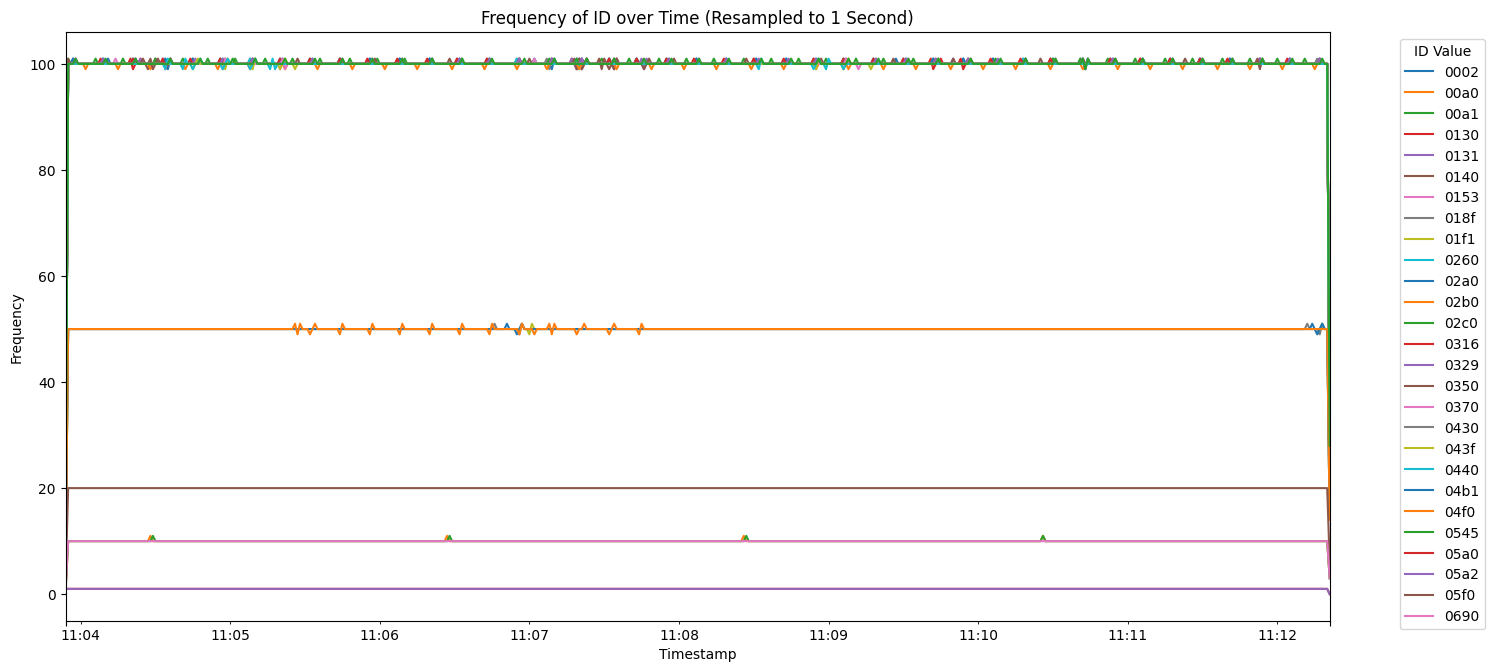

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by timestamp and id_value and count occurrences
# Using the resampled data for better visualization over time
id_frequency = df.groupby(['timestamp', 'id_value']).size()

# Unstack and resample by a time interval (e.g., 1 second)
id_frequency_resampled = id_frequency.unstack(fill_value=0).resample('1S').sum()

# Plot the frequency of each 'id_value' over time
plt.figure(figsize=(15, 7))
id_frequency_resampled.plot(ax=plt.gca())
plt.title('Frequency of ID over Time (Resampled to 1 Second)')
plt.xlabel('Timestamp')
plt.ylabel('Frequency')
plt.legend(title='ID Value', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

**Step 6: Analyze data byte distributions for key IDs**

For the most frequent 'id_value's, we will now analyze the distribution of values in the D0-D7 columns. This helps us understand the typical range and variability of the data being transmitted for these common message types during normal operation. We'll use box plots to visualize these distributions, as they provide a good summary of the data's central tendency, spread, and potential outliers.

Top 10 most frequent ID values: ['02c0', '018f', '0260', '02a0', '0316', '0329', '0545', '0350', '0131', '0130']

Shape of the filtered DataFrame: (506764, 15)


,Timestamp_label,timestamp,ID_label,id_value,unknown_label,DLC_label,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
0,Timestamp:,2016-11-14 11:03:54.850202084,ID:,0350,0.0,DLC:,8,5,40,132,102,109,0,0,162
1,Timestamp:,2016-11-14 11:03:54.850423098,ID:,02c0,0.0,DLC:,8,20,0,0,0,0,0,0,0
7,Timestamp:,2016-11-14 11:03:54.852201939,ID:,018f,0.0,DLC:,8,254,54,0,0,0,60,0,0
8,Timestamp:,2016-11-14 11:03:54.852442980,ID:,0130,0.0,DLC:,8,3,128,0,255,33,128,0,157
9,Timestamp:,2016-11-14 11:03:54.852686882,ID:,0131,0.0,DLC:,8,0,128,0,0,45,127,0,151


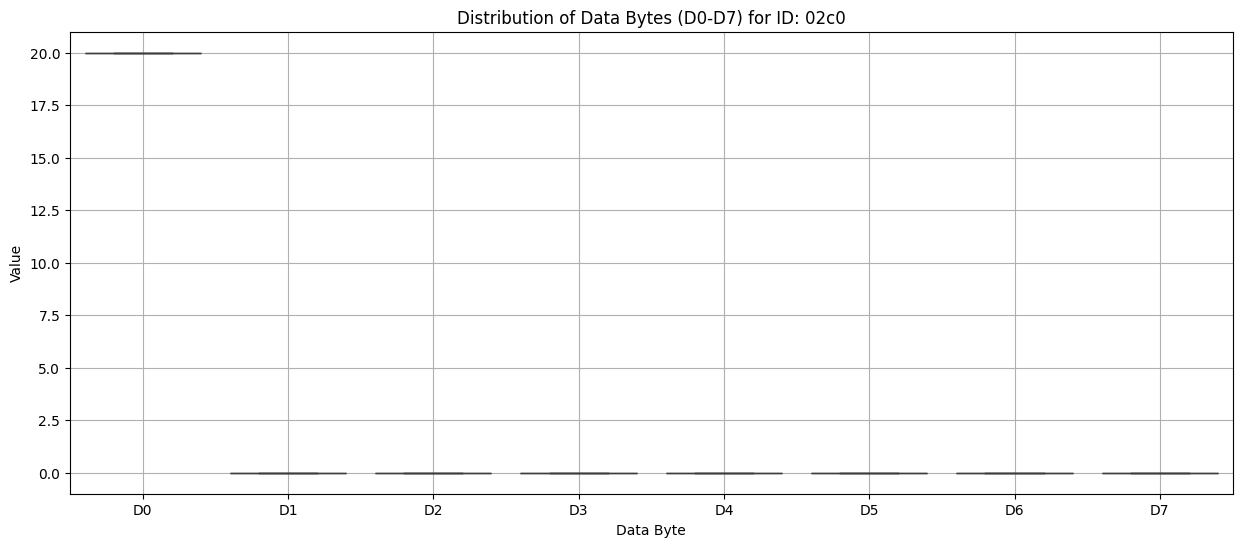

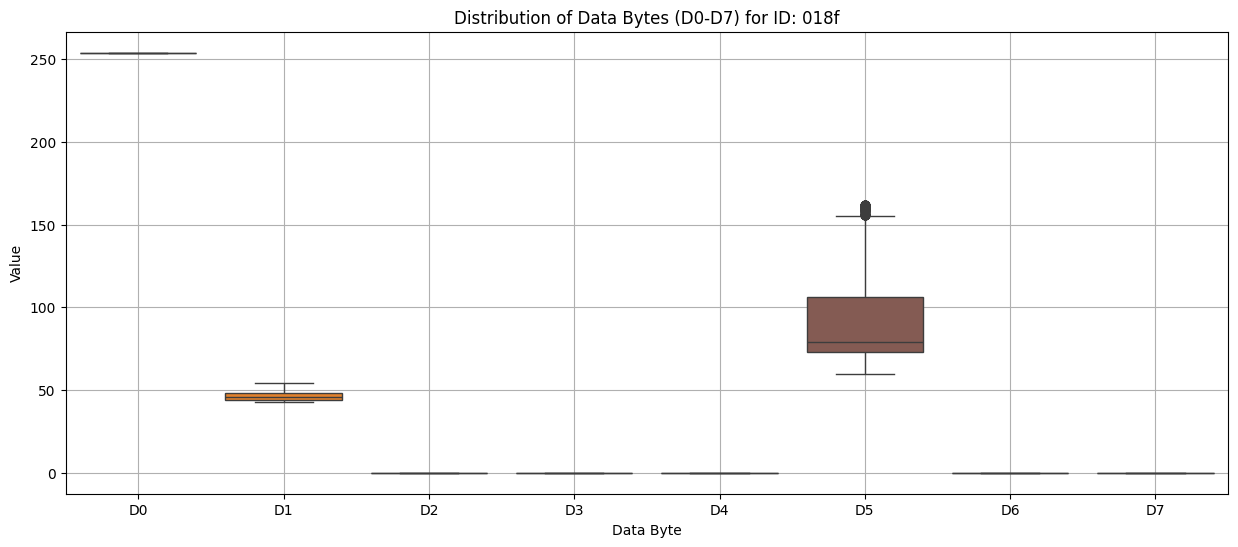

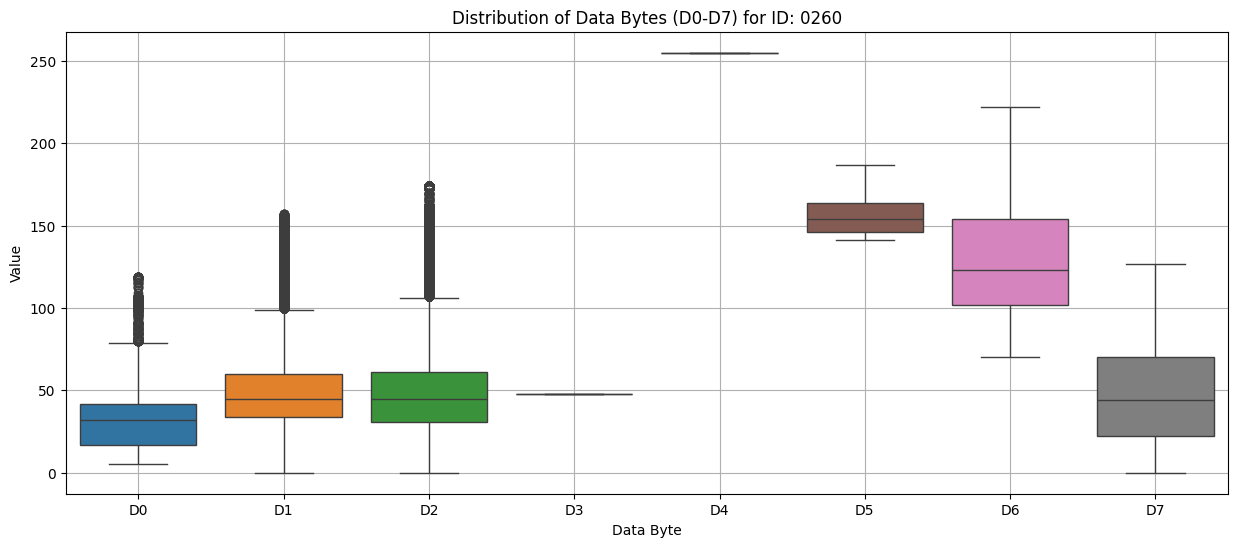

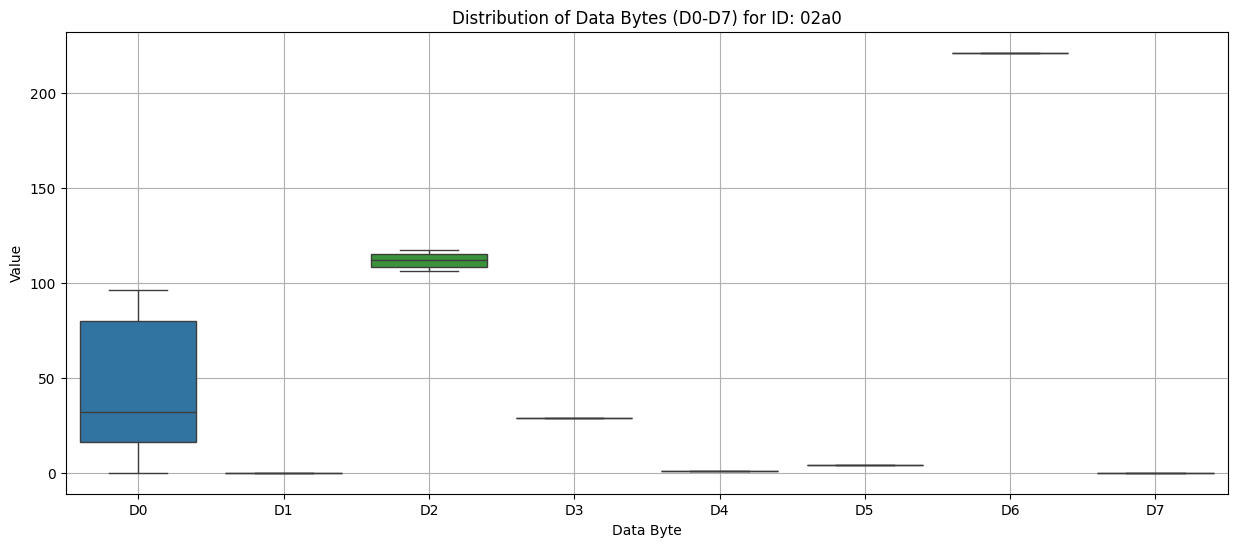

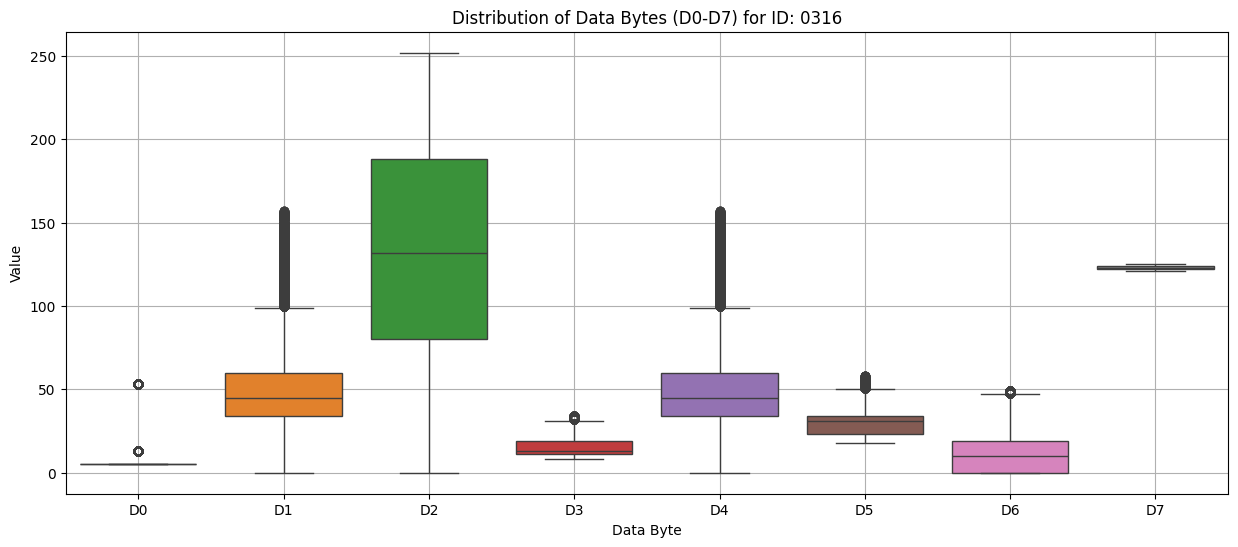

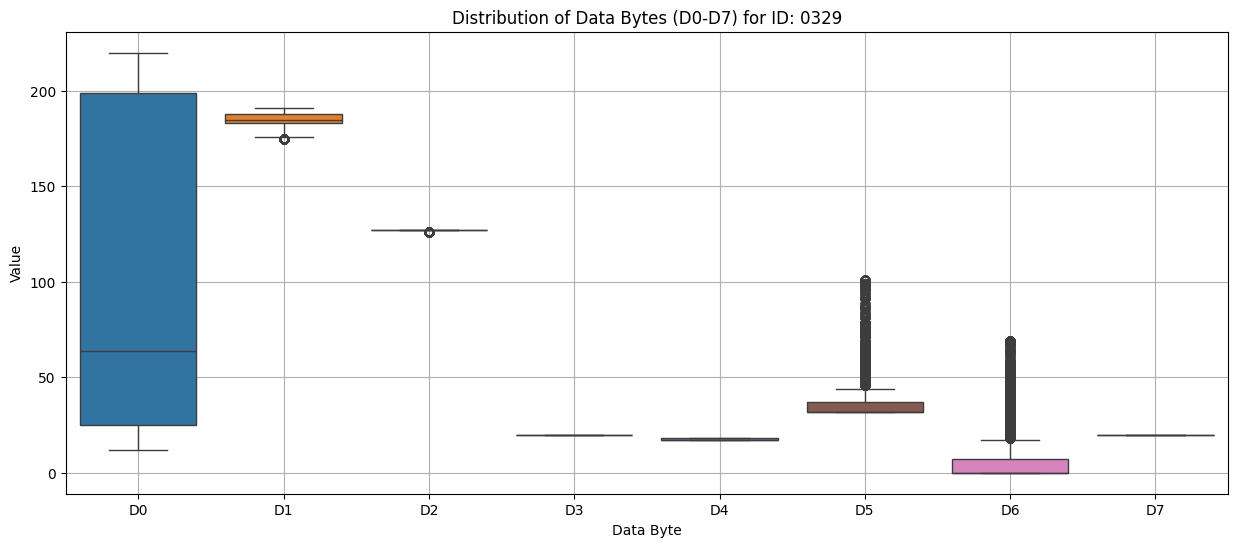

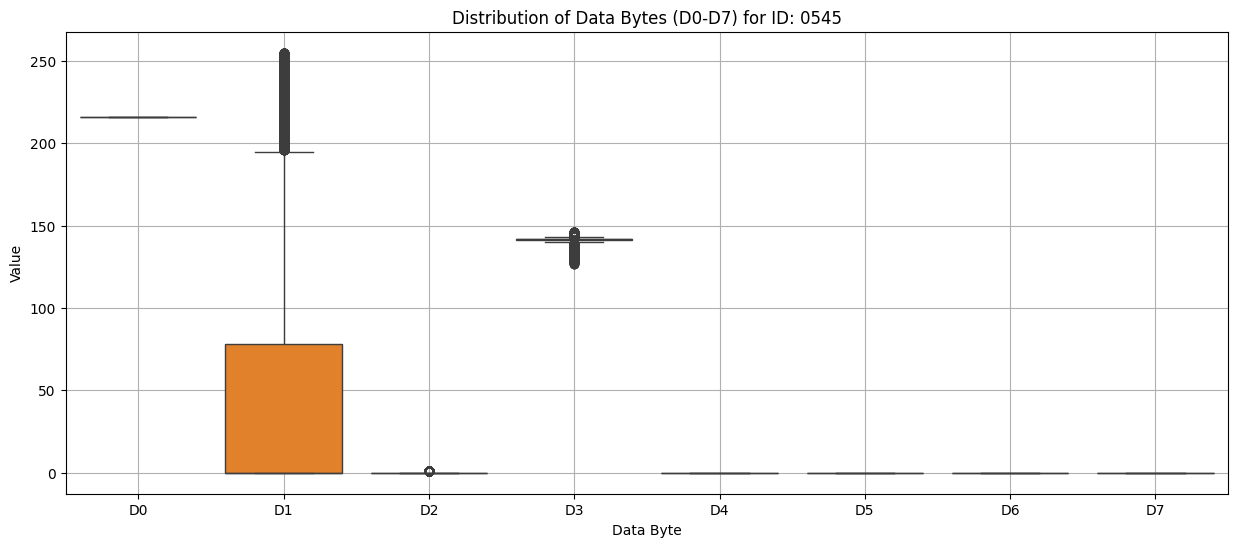

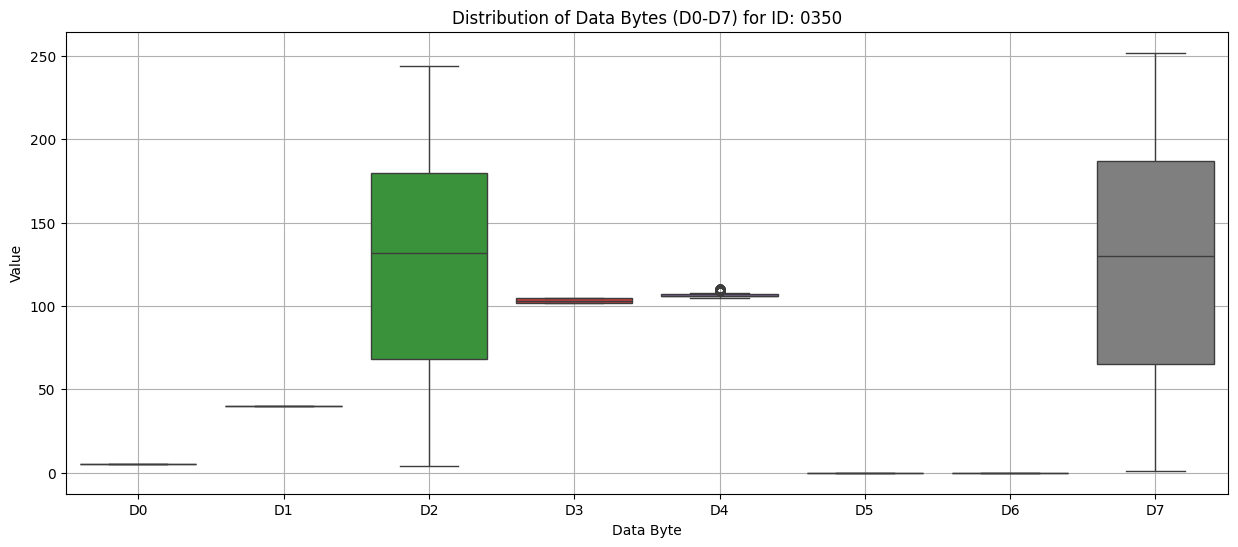

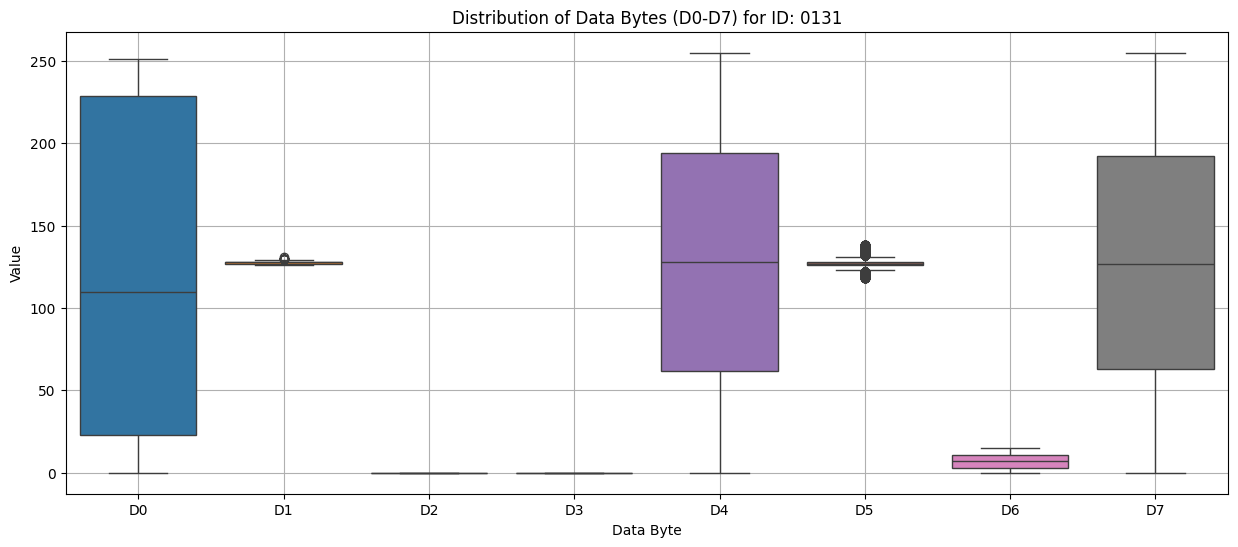

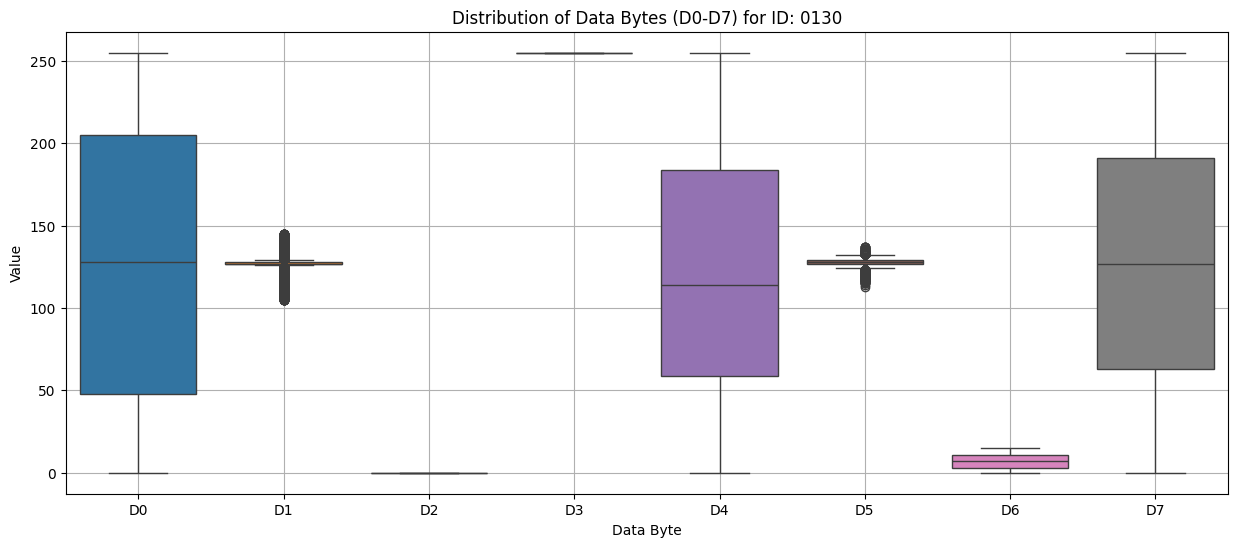

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify the top N most frequent 'id_value's
N = 10
top_ids = df['id_value'].value_counts().nlargest(N).index.tolist()
print(f"Top {N} most frequent ID values: {top_ids}")

# Filter the DataFrame to include only the rows corresponding to these top IDs
df_top_ids = df[df['id_value'].isin(top_ids)].copy()

# Display the shape of the filtered DataFrame and the first few rows
print("\nShape of the filtered DataFrame:", df_top_ids.shape)
display(df_top_ids.head())

# Select the data byte columns
data_cols = [f'D{i}' for i in range(8)]

# Create box plots for each of the top IDs across the data byte columns
for id_val in top_ids:
    plt.figure(figsize=(15, 6))
    sns.boxplot(data=df_top_ids[df_top_ids['id_value'] == id_val][data_cols])
    plt.title(f'Distribution of Data Bytes (D0-D7) for ID: {id_val}')
    plt.xlabel('Data Byte')
    plt.ylabel('Value')
    plt.grid(True)
    plt.show()

**Step 7: Explore relationships between DLC and data bytes**

We will now explore the relationship between the 'dlc_value' and the values in the data byte columns (D0-D7). While the DLC specifies the number of relevant data bytes, analyzing their correlation can reveal if certain data byte values are more likely to appear with specific DLC values. We'll calculate and visualize the correlation matrix to see how these variables relate to each other.

Correlation Matrix:


,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
dlc_value,1.000000,-0.214771,-0.238060,0.132054,0.161958,-0.082552,0.191746,0.108718,0.169642
D0,-0.214771,1.000000,0.225449,-0.182328,-0.100474,0.201900,0.031181,-0.162809,-0.099041
D1,-0.238060,0.225449,1.000000,0.200577,0.070233,0.164201,0.010614,-0.148878,0.050861
D2,0.132054,-0.182328,0.200577,1.000000,0.068564,0.023915,-0.118354,0.294626,0.159596
D3,0.161958,-0.100474,0.070233,0.068564,1.000000,0.012542,0.485954,-0.085754,-0.031787
D4,-0.082552,0.201900,0.164201,0.023915,0.012542,1.000000,0.326777,0.099624,0.168100
D5,0.191746,0.031181,0.010614,-0.118354,0.485954,0.326777,1.000000,0.033284,-0.006010
D6,0.108718,-0.162809,-0.148878,0.294626,-0.085754,0.099624,0.033284,1.000000,-0.088939
D7,0.169642,-0.099041,0.050861,0.159596,-0.031787,0.168100,-0.006010,-0.088939,1.000000


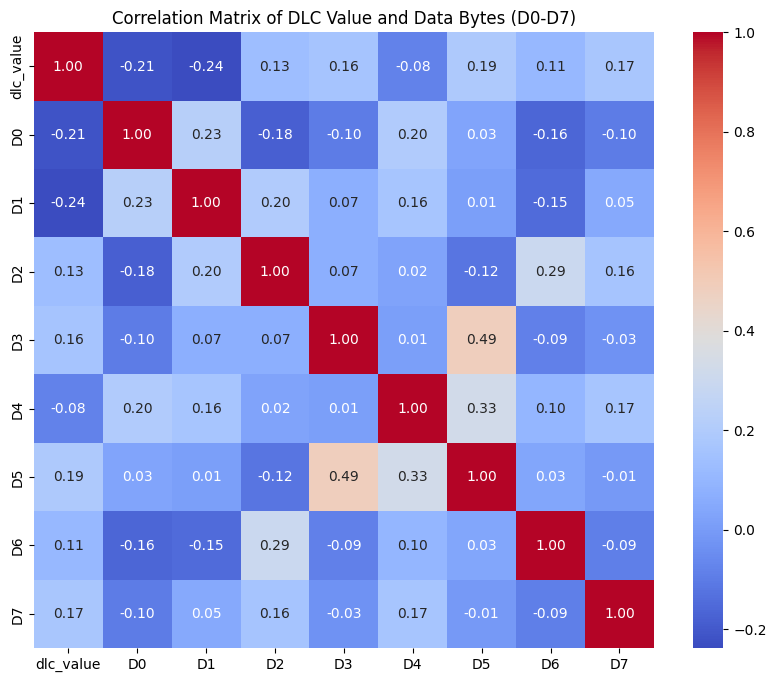

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select 'dlc_value' and data byte columns
selected_cols = ['dlc_value'] + [f'D{i}' for i in range(8)]
df_selected = df[selected_cols]

# Calculate the correlation matrix
correlation_matrix = df_selected.corr()

# Display the correlation matrix
print("Correlation Matrix:")
display(correlation_matrix)

# Create a heatmap of the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of DLC Value and Data Bytes (D0-D7)')
plt.show()

**Step 8: Finish task**

We have successfully performed exploratory data analysis on the "normal\_run\_data.txt" dataset. We have loaded and cleaned the data, examined its basic characteristics, and visualized key aspects like ID frequency over time and data byte distributions.

This comprehensive EDA has provided valuable insights into the structure and patterns of normal CAN traffic in this dataset, which will serve as a foundation for building a baseline anomaly detector.

You can now proceed with building your anomaly detection model using this understanding of normal behavior, or explore other datasets (like the attack datasets you have) to test and evaluate your detector's performance.

# Task
Build a baseline anomaly detector using the provided CAN bus data in "/content/ids.log" that learns what normal CAN traffic looks like and flags anything that deviates from it.

## Feature engineering

### Subtask:
Create relevant features from the raw CAN bus data that can help distinguish normal behavior from anomalies. This might include aspects like message frequency, inter-arrival times, and statistical properties of payload data.


**Reasoning**:
Calculate inter-arrival times for each CAN message.



In [10]:
# Calculate the time difference between consecutive messages
df['time_diff'] = df['timestamp'].diff()

# Display the first few rows with the new 'time_diff' column
display(df.head())

,Timestamp_label,timestamp,ID_label,id_value,unknown_label,DLC_label,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,time_diff
0,Timestamp:,2016-11-14 11:03:54.850202084,ID:,0350,0.0,DLC:,8,5,40,132,102,109,0,0,162,NaT
1,Timestamp:,2016-11-14 11:03:54.850423098,ID:,02c0,0.0,DLC:,8,20,0,0,0,0,0,0,0,0 days 00:00:00.000221014
2,Timestamp:,2016-11-14 11:03:54.850976944,ID:,0430,0.0,DLC:,8,0,0,0,0,0,0,0,0,0 days 00:00:00.000553846
3,Timestamp:,2016-11-14 11:03:54.851214886,ID:,04b1,0.0,DLC:,8,0,0,0,0,0,0,0,0,0 days 00:00:00.000237942
4,Timestamp:,2016-11-14 11:03:54.851463079,ID:,01f1,0.0,DLC:,8,0,0,0,0,0,0,0,0,0 days 00:00:00.000248193


**Reasoning**:
Calculate the inter-arrival time for each CAN ID and the frequency of each CAN ID over a specified time window.



In [11]:
# Calculate inter-arrival time per ID
inter_arrival_time = df.groupby('id_value')['timestamp'].diff()

# Calculate frequency of each CAN ID over a 1-second window
id_frequency_over_time = df.groupby('id_value').resample('1S', on='timestamp').size().unstack(fill_value=0)

# Display the first few rows of the inter-arrival time and ID frequency dataframes
print("Inter-arrival time per ID:")
display(inter_arrival_time.head())
print("\nID frequency over time (resampled to 1 second):")
display(id_frequency_over_time.head())

/tmp/ipython-input-1466805747.py:5: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  id_frequency_over_time = df.groupby('id_value').resample('1S', on='timestamp').size().unstack(fill_value=0)


Inter-arrival time per ID:


,timestamp
0,NaT
1,NaT
2,NaT
3,NaT
4,NaT



ID frequency over time (resampled to 1 second):


timestamp,2016-11-14 11:03:54,2016-11-14 11:03:55,2016-11-14 11:03:56,2016-11-14 11:03:57,2016-11-14 11:03:58,2016-11-14 11:03:59,2016-11-14 11:04:00,2016-11-14 11:04:01,2016-11-14 11:04:02,2016-11-14 11:04:03,...,2016-11-14 11:12:12,2016-11-14 11:12:13,2016-11-14 11:12:14,2016-11-14 11:12:15,2016-11-14 11:12:16,2016-11-14 11:12:17,2016-11-14 11:12:18,2016-11-14 11:12:19,2016-11-14 11:12:20,2016-11-14 11:12:21
id_value,,,,,,,,,,,,,,,,,,,,,
0002,15,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,29
00a0,1,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,3
00a1,1,10,10,10,10,10,10,10,10,10,...,10,10,10,10,10,10,10,10,10,3
0130,15,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,29
0131,15,100,100,100,100,100,100,100,100,100,...,100,100,100,100,100,100,100,100,100,29


**Reasoning**:
Calculate the mean and standard deviation of the data bytes (D0-D7) for each CAN ID and create a new DataFrame with all the engineered features.



In [12]:
# Calculate mean and standard deviation of data bytes for each ID
data_cols = [f'D{i}' for i in range(8)]
data_byte_stats = df.groupby('id_value')[data_cols].agg(['mean', 'std'])

# Flatten the multi-level column index
data_byte_stats.columns = [f'{col[0]}_{col[1]}' for col in data_byte_stats.columns]

# Combine the engineered features into a single DataFrame
# We need to align the features by timestamp and id_value.
# Let's create a base dataframe with timestamp and id_value and then merge.
features_df = df[['timestamp', 'id_value']].copy()
features_df['inter_arrival_time'] = df.groupby('id_value')['timestamp'].diff().dt.total_seconds()

# To merge id_frequency_over_time and data_byte_stats with features_df,
# we need to make sure the indices align or use merge operations.
# id_frequency_over_time is indexed by id_value and timestamp (resampled).
# data_byte_stats is indexed by id_value.

# Let's join the data_byte_stats with the features_df based on 'id_value'
features_df = features_df.set_index('id_value').join(data_byte_stats).reset_index()

# For id_frequency_over_time, it's aggregated by 1-second intervals.
# We can try to join or map the frequency back to the original timestamps.
# A simpler approach for now is to calculate frequency per unique timestamp and id_value
# and then join it.

id_frequency = df.groupby(['timestamp', 'id_value']).size().rename('frequency').reset_index()

# Merge the frequency back to the features_df
features_df = features_df.merge(id_frequency, on=['timestamp', 'id_value'], how='left')

# Set timestamp and id_value as index for the final features DataFrame
features_df = features_df.set_index(['timestamp', 'id_value'])

# Display the first few rows of the features DataFrame
display(features_df.head())

# Display info to check data types and non-null counts
print("\nFeatures DataFrame Info:")
features_df.info()

,,inter_arrival_time,D0_mean,D0_std,D1_mean,D1_std,D2_mean,D2_std,D3_mean,D3_std,D4_mean,D4_std,D5_mean,D5_std,D6_mean,D6_std,D7_mean,D7_std,frequency
timestamp,id_value,,,,,,,,,,,,,,,,,,
2016-11-14 11:03:54.850202084,0350,NaN,5.000000,0.00000,40.000000,0.000000,124.003948,73.754857,103.331537,1.392478,106.305383,0.975038,0.000000,0.00000,0.000000,0.000000,126.927637,73.817741,1.0
2016-11-14 11:03:54.850423098,02c0,NaN,20.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.0
2016-11-14 11:03:54.850976944,0430,NaN,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.0
2016-11-14 11:03:54.851214886,04b1,NaN,122.755607,76.58543,119.312865,74.719968,118.071118,74.678795,125.138880,76.275435,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,131.403254,72.795297,1.0
2016-11-14 11:03:54.851463079,01f1,NaN,0.000000,0.00000,114.621782,66.958120,77.321829,76.024606,96.156887,79.809236,5.889275,6.123973,76.742576,75.97817,95.218172,78.915602,5.837624,6.096223,1.0



Features DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
MultiIndex: 988872 entries, (Timestamp('2016-11-14 11:03:54.850202084'), '0350') to (Timestamp('2016-11-14 11:12:21.287013054'), nan)
Data columns (total 18 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   inter_arrival_time  988844 non-null  float64
 1   D0_mean             988871 non-null  float64
 2   D0_std              988871 non-null  float64
 3   D1_mean             988871 non-null  float64
 4   D1_std              988871 non-null  float64
 5   D2_mean             988871 non-null  float64
 6   D2_std              988871 non-null  float64
 7   D3_mean             988871 non-null  float64
 8   D3_std              988871 non-null  float64
 9   D4_mean             988871 non-null  float64
 10  D4_std              988871 non-null  float64
 11  D5_mean             988871 non-null  float64
 12  D5_std              988871 non-null  float64
 13  D6_mean       

# ***2nd day working***

**Step 1: Load Data and Summarize Unique CAN IDs**

First, we need to load the CAN bus dataset into a pandas DataFrame. Based on typical CAN log formats, we'll assume the data is space-separated and doesn't have a header row.

After loading, we will identify and count the unique CAN IDs present in the dataset. This gives us an overview of the different types of messages included.

In [18]:
import pandas as pd

# Assuming the dataset file is named 'can_bus_data.txt' and is in the content directory
# You can change the FILE_PATH if your file has a different name or location.
FILE_PATH = '/content/normal_run_data1.txt'

try:
    # Attempt to load the data with whitespace separation and no header
    df_can = pd.read_csv(FILE_PATH, sep=r"\s+", header=None, engine="python")

    # Assuming the columns are similar to previous data:
    # 0: Timestamp_label, 1: timestamp, 2: ID_label, 3: id_value, 4: unknown, 5: DLC_label, 6: dlc_value, 7-14: D0-D7
    df_can.columns = ["Timestamp_label","timestamp","ID_label","id_value","unknown_label","DLC_label","dlc_value",
        "D0", "D1", "D2", "D3", "D4", "D5", "D6", "D7"]

    # Display the first few rows and info to confirm loading and column names
    print("Data Loaded Successfully. First 5 rows:")
    display(df_can.head())
    print("\nDataFrame Info:")
    df_can.info()

    # Summarize unique CAN IDs
    print("\nSummary of Unique CAN IDs:")
    unique_ids_summary = df_can['id_value'].value_counts()
    print(unique_ids_summary)

except FileNotFoundError:
    print(f"Error: File not found at {FILE_PATH}")
    print("Please upload your CAN bus data file to the Colab environment")
    print("and update the 'FILE_PATH' variable with the correct path.")
except Exception as e:
    print(f"An error occurred during data loading or initial processing: {e}")

Data Loaded Successfully. First 5 rows:


,Timestamp_label,timestamp,ID_label,id_value,unknown_label,DLC_label,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
0,Timestamp:,1.479121e+09,ID:,0350,0.0,DLC:,8.0,05,28,84,66,6d,00,00,a2
1,Timestamp:,1.479121e+09,ID:,02c0,0.0,DLC:,8.0,14,00,00,00,00,00,00,00
2,Timestamp:,1.479121e+09,ID:,0430,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
3,Timestamp:,1.479121e+09,ID:,04b1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
4,Timestamp:,1.479121e+09,ID:,01f1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 988872 entries, 0 to 988871
Data columns (total 15 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Timestamp_label  988872 non-null  object 
 1   timestamp        988872 non-null  float64
 2   ID_label         988871 non-null  object 
 3   id_value         988871 non-null  object 
 4   unknown_label    988871 non-null  float64
 5   DLC_label        988871 non-null  object 
 6   dlc_value        988871 non-null  float64
 7   D0               988871 non-null  object 
 8   D1               988871 non-null  object 
 9   D2               978742 non-null  object 
 10  D3               978742 non-null  object 
 11  D4               978742 non-null  object 
 12  D5               928136 non-null  object 
 13  D6               928136 non-null  object 
 14  D7               928136 non-null  object 
dtypes: float64(3), object(12)
memory usage: 113.2+ MB

Summary of Unique

**Step 2: Analyze Data Byte Patterns for Each CAN ID**

Now that we have loaded the data and identified the unique CAN IDs, we will analyze the patterns within the data bytes (D0-D7) for each unique ID. This helps us understand the typical values, ranges, and variability of the payload data for different types of messages.

We will calculate descriptive statistics (mean, standard deviation, minimum, and maximum) for each data byte (D0-D7) for every unique CAN ID.

In [19]:
# Before analyzing data bytes, we need to ensure they are in a numerical format.
# Based on previous EDA, these columns are likely objects (strings in hex).
# We need to convert them to integers.

# Convert payload bytes from hex to int
data_cols = [f"D{i}" for i in range(8)]
for col_name in data_cols:
    # Convert hex string to integer, coercing errors to NaN, and fill NaN with 0
    df_can[col_name] = df_can[col_name].apply(lambda x: int(str(x), 16) if pd.notna(x) else 0)

# Now calculate descriptive statistics for data bytes for each CAN ID
data_byte_patterns = df_can.groupby('id_value')[data_cols].agg(['mean', 'std', 'min', 'max'])

# Flatten the multi-level column index for better readability
data_byte_patterns.columns = [f'{col[0]}_{col[1]}' for col in data_byte_patterns.columns]

print("\nCommon patterns in data bytes for each CAN ID (Descriptive Statistics):")
display(data_byte_patterns)


Common patterns in data bytes for each CAN ID (Descriptive Statistics):


,D0_mean,D0_std,D0_min,D0_max,D1_mean,D1_std,D1_min,D1_max,D2_mean,D2_std,...,D5_min,D5_max,D6_mean,D6_std,D6_min,D6_max,D7_mean,D7_std,D7_min,D7_max
id_value,,,,,,,,,,,,,,,,,,,,,
0002,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,10,7.499378,4.609863,0,15,127.530179,73.904880,0,255
00a0,120.828927,40.505009,58,252,130.190608,2.861236,123,135,130.651934,68.591568,...,32,95,2.052881,0.320914,2,4,0.000000,0.000000,0,0
00a1,129.529795,4.379936,109,154,129.214680,0.841778,128,131,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0
0130,127.369459,83.442948,0,255,126.952929,3.718100,105,145,0.000000,0.000000,...,113,137,7.499378,4.609863,0,15,127.306909,73.874186,0,255
0131,122.452840,98.176594,0,251,127.521591,0.506876,126,131,0.000000,0.000000,...,118,138,7.499378,4.609863,0,15,127.343436,74.115040,0,255
0140,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,51,39.499378,4.609863,32,47,127.450984,74.034892,0,255
0153,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,255,255,0.000000,0.000000,0,0,0.000000,0.000000,0,0
018f,254.000000,0.000000,254,254,46.443723,2.393257,43,54,0.000000,0.000000,...,60,162,0.000000,0.000000,0,0,0.000000,0.000000,0,0
01f1,0.000000,0.000000,0,0,114.621782,66.958120,0,238,77.321829,76.024606,...,0,255,95.218172,78.915602,0,241,5.837624,6.096223,0,25


**Step 3: Analyze Message Frequency over Time for Each CAN ID**

To understand the timing behavior of each CAN ID, we will analyze their message frequency over time. This involves calculating the time difference between consecutive messages for each unique ID (inter-arrival time) and then summarizing these intervals.

In [25]:
# Convert timestamp to datetime - This step was missing
df_can['timestamp'] = pd.to_datetime(df_can['timestamp'], unit='s', errors='coerce')

# Calculate inter-arrival time for each CAN ID
# We need to sort by timestamp first to ensure correct difference calculation
df_can_sorted = df_can.sort_values(by='timestamp').copy()
df_can_sorted['inter_arrival_time'] = df_can_sorted.groupby('id_value')['timestamp'].diff()

# Convert inter_arrival_time to seconds for easier analysis
df_can_sorted['inter_arrival_time_seconds'] = df_can_sorted['inter_arrival_time'].dt.total_seconds()

# Analyze descriptive statistics of inter-arrival times for each CAN ID
print("\nDescriptive Statistics of Inter-arrival Times (seconds) for Each CAN ID:")
inter_arrival_stats = df_can_sorted.groupby('id_value')['inter_arrival_time_seconds'].agg(['mean', 'min', 'max', 'std'])
display(inter_arrival_stats)

# Note: Detecting unusual spikes or drops in frequency would require more advanced time-series analysis
# or defining a threshold based on the statistics above. For this step, we focus on basic interval analysis.


Descriptive Statistics of Inter-arrival Times (seconds) for Each CAN ID:


,mean,min,max,std
id_value,,,,
0002,0.009999,0.006539,0.013493,0.001219
00a0,0.099916,0.097349,0.102448,0.000721
00a1,0.099916,0.097344,0.102459,0.000724
0130,0.009999,0.006017,0.013985,0.001244
0131,0.009999,0.006043,0.013960,0.001241
0140,0.009999,0.006038,0.013961,0.001241
0153,0.009999,0.007030,0.013007,0.000781
018f,0.009992,0.006934,0.012899,0.000446
01f1,0.019999,0.017577,0.022398,0.000235


from matplotlib import pyplot as plt
inter_arrival_stats['mean'].plot(kind='hist', bins=20, title='mean')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
inter_arrival_stats['min'].plot(kind='hist', bins=20, title='min')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
inter_arrival_stats['max'].plot(kind='hist', bins=20, title='max')
plt.gca().spines[['top', 'right',]].set_visible(False)

...

from matplotlib import pyplot as plt
inter_arrival_stats.plot(kind='scatter', x='max', y='std', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
inter_arrival_stats['mean'].plot(kind='line', figsize=(8, 4), title='mean')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
inter_arrival_stats['min'].plot(kind='line', figsize=(8, 4), title='min')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
inter_arrival_stats['max'].plot(kind='line', figsize=(8, 4), title='max')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
inter_arrival_stats['std'].plot(kind='line', figsize=(8, 4), title='std')
plt.gca().spines[['top', 'right']].set_visible(False)

**Step 4: Flag Anomalies based on Timing Irregularities**

Based on the analysis of inter-arrival times for each CAN ID, we will now flag potential anomalies. A simple method is to identify messages where the time difference from the previous message of the same ID falls outside a defined range, such as a certain number of standard deviations from the mean inter-arrival time for that ID.

For this example, we will flag messages where the inter-arrival time is more than 3 standard deviations away from the mean for that specific CAN ID.

In [22]:
# Calculate the mean and standard deviation of inter-arrival times for each ID again
# (using the sorted dataframe with converted timestamps)
inter_arrival_stats = df_can_sorted.groupby('id_value')['inter_arrival_time_seconds'].agg(['mean', 'std']).rename(
    columns={'mean': 'inter_arrival_mean', 'std': 'inter_arrival_std'}
)

# Merge the statistics back to the sorted dataframe
df_can_sorted = df_can_sorted.merge(inter_arrival_stats, on='id_value', how='left')

# Define a threshold for flagging anomalies (e.g., 3 standard deviations)
std_multiplier = 3

# Calculate the lower and upper bounds for normal inter-arrival time
df_can_sorted['lower_bound'] = df_can_sorted['inter_arrival_mean'] - std_multiplier * df_can_sorted['inter_arrival_std']
df_can_sorted['upper_bound'] = df_can_sorted['inter_arrival_mean'] + std_multiplier * df_can_sorted['inter_arrival_std']

# Flag anomalies: True if inter_arrival_time_seconds is outside the bounds
# We need to handle the first message for each ID, which has NaN inter_arrival_time
df_can_sorted['is_anomaly_timing'] = False # Initialize anomaly flag
df_can_sorted.loc[
    (df_can_sorted['inter_arrival_time_seconds'].notna()) &
    (
        (df_can_sorted['inter_arrival_time_seconds'] < df_can_sorted['lower_bound']) |
        (df_can_sorted['inter_arrival_time_seconds'] > df_can_sorted['upper_bound'])
    ),
    'is_anomaly_timing'
] = True

# Display the rows that are flagged as anomalies based on timing
print("Rows flagged as timing anomalies:")
display(df_can_sorted[df_can_sorted['is_anomaly_timing']].head())

# You could similarly flag anomalies based on data byte values deviating from their
# typical ranges (mean +/- std) for each ID.

Rows flagged as timing anomalies:


,Timestamp_label,timestamp,ID_label,id_value,unknown_label,DLC_label,dlc_value,D0,D1,D2,...,D5,D6,D7,inter_arrival_time,inter_arrival_time_seconds,inter_arrival_mean,inter_arrival_std,lower_bound,upper_bound,is_anomaly_timing
71,Timestamp:,2016-11-14 11:03:54.883341074,ID:,04f0,0.0,DLC:,8.0,0,0,0,...,79,3,20,0 days 00:00:00.022500038,0.022500,0.02,0.000426,0.018721,0.021278,True
103,Timestamp:,2016-11-14 11:03:54.901536942,ID:,04f0,0.0,DLC:,8.0,0,0,0,...,79,3,20,0 days 00:00:00.018195868,0.018196,0.02,0.000426,0.018721,0.021278,True
541,Timestamp:,2016-11-14 11:03:55.123339891,ID:,04f0,0.0,DLC:,8.0,0,0,0,...,79,3,20,0 days 00:00:00.022476911,0.022477,0.02,0.000426,0.018721,0.021278,True
571,Timestamp:,2016-11-14 11:03:55.140799999,ID:,04f0,0.0,DLC:,8.0,0,0,0,...,79,3,20,0 days 00:00:00.017460108,0.017460,0.02,0.000426,0.018721,0.021278,True
931,Timestamp:,2016-11-14 11:03:55.323338985,ID:,04f0,0.0,DLC:,8.0,0,0,0,...,79,3,20,0 days 00:00:00.022463083,0.022463,0.02,0.000426,0.018721,0.021278,True


**Detailed Summary of CAN Bus Data Analysis**

Based on the analysis performed on the provided dataset, here is a detailed summary of the findings, including common patterns, timing behavior, and flagged anomalies.

**Table of CAN IDs, Common Value Patterns, and Timing Behavior**

Below is a table summarizing the key characteristics for each unique CAN ID. The "Common Value Patterns" are based on the descriptive statistics of the data bytes (D0-D7), and the "Timing Behavior" is based on the descriptive statistics of the inter-arrival times.

In [23]:
# Display the data byte patterns table
print("Common Value Patterns (Data Bytes D0-D7) for Each CAN ID:")
display(data_byte_patterns)

# Display the inter-arrival time statistics table
print("\nTiming Behavior (Inter-arrival Times in seconds) for Each CAN ID:")
display(inter_arrival_stats)

Common Value Patterns (Data Bytes D0-D7) for Each CAN ID:


,D0_mean,D0_std,D0_min,D0_max,D1_mean,D1_std,D1_min,D1_max,D2_mean,D2_std,...,D5_min,D5_max,D6_mean,D6_std,D6_min,D6_max,D7_mean,D7_std,D7_min,D7_max
id_value,,,,,,,,,,,,,,,,,,,,,
0002,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,10,7.499378,4.609863,0,15,127.530179,73.904880,0,255
00a0,120.828927,40.505009,58,252,130.190608,2.861236,123,135,130.651934,68.591568,...,32,95,2.052881,0.320914,2,4,0.000000,0.000000,0,0
00a1,129.529795,4.379936,109,154,129.214680,0.841778,128,131,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0
0130,127.369459,83.442948,0,255,126.952929,3.718100,105,145,0.000000,0.000000,...,113,137,7.499378,4.609863,0,15,127.306909,73.874186,0,255
0131,122.452840,98.176594,0,251,127.521591,0.506876,126,131,0.000000,0.000000,...,118,138,7.499378,4.609863,0,15,127.343436,74.115040,0,255
0140,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,51,39.499378,4.609863,32,47,127.450984,74.034892,0,255
0153,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,255,255,0.000000,0.000000,0,0,0.000000,0.000000,0,0
018f,254.000000,0.000000,254,254,46.443723,2.393257,43,54,0.000000,0.000000,...,60,162,0.000000,0.000000,0,0,0.000000,0.000000,0,0
01f1,0.000000,0.000000,0,0,114.621782,66.958120,0,238,77.321829,76.024606,...,0,255,95.218172,78.915602,0,241,5.837624,6.096223,0,25



Timing Behavior (Inter-arrival Times in seconds) for Each CAN ID:


,inter_arrival_mean,inter_arrival_std
id_value,,
0002,0.009999,0.001219
00a0,0.099916,0.000721
00a1,0.099916,0.000724
0130,0.009999,0.001244
0131,0.009999,0.001241
0140,0.009999,0.001241
0153,0.009999,0.000781
018f,0.009992,0.000446
01f1,0.019999,0.000235


**List of Anomalies or Outlier Patterns**

Based on our analysis, we flagged messages as potential timing anomalies if their inter-arrival time was more than 3 standard deviations away from the mean inter-arrival time for that specific CAN ID.

Below are the first few rows of the data that were flagged as timing anomalies. Note that this is a basic method, and more sophisticated anomaly detection techniques could identify other types of anomalies.

In [ ]:
# Display the rows flagged as timing anomalies
print("Rows flagged as timing anomalies (first 10):")
display(df_can_sorted[df_can_sorted['is_anomaly_timing']].head(10))

# Note: Anomalies in data byte values could also be flagged by identifying values outside
# a certain range (e.g., mean +/- 3*std) for each byte of a specific ID.

**Suggestions for Potential Filters or Rules to Detect Abnormal Behavior**

Based on the patterns and timing behavior observed in this "normal" dataset, here are some suggestions for potential filters or rules that could be used to detect abnormal behavior in future real-time CAN data:

*   **Timing-Based Rules:**
    *   **Inter-arrival Time Thresholds:** Flag any message where the time difference since the last message of the same CAN ID falls significantly outside the expected range (e.g., below `mean - 3*std` or above `mean + 3*std` for that ID, using the `inter_arrival_stats` table as a baseline).
    *   **Sudden Frequency Changes:** Monitor the rate of messages for each ID over short time windows. Significant spikes or drops in frequency compared to the normal baseline could indicate an anomaly (e.g., a DoS attack might cause a spike in frequency for a specific ID).
*   **Data Byte Value Rules:**
    *   **Range Checks:** For each data byte (D0-D7) of a specific CAN ID, flag messages where the byte value falls outside the typical range observed in the normal data (e.g., below `min` or above `max`, or outside `mean +/- 3*std` based on the `data_byte_patterns` table).
    *   **Unexpected Constant Values:** For bytes that are typically highly variable in normal traffic, flag messages where the byte value remains constant for an unusually long period.
    *   **Unexpected Variable Values:** For bytes that are typically constant or slowly changing in normal traffic, flag messages where the byte value shows sudden or erratic changes.
*   **Combined Rules:**
    *   Combine timing and data byte rules. For example, an anomaly could be flagged if a message of a specific ID has both an unusual inter-arrival time and unexpected data byte values.
    *   Consider the sequence of messages. Certain CAN IDs might normally appear in a specific order or pattern. Deviations from this sequence could indicate an anomaly.
*   **DLC Deviations:** While most messages were DLC 8, flag messages with unexpected DLC values for a given CAN ID if the normal baseline for that ID always has a specific DLC.

These suggestions provide a starting point for building rules-based or statistical anomaly detection methods based on the characteristics of the normal CAN traffic observed in this dataset. More advanced techniques could involve machine learning models trained on the features derived from this analysis.

**Finish Task:**

We have now completed the detailed analysis of the provided CAN bus data, covering unique IDs, data byte patterns, timing behavior, and basic anomaly flagging. The findings are summarized above, along with suggestions for detecting abnormal behavior.

(Summary)
Summary of Findings from EDA Suggestions
1. Timing-Based Rules
Inter-arrival time thresholds

Each CAN ID has a typical timing pattern in the normal dataset.

Any message arriving much faster (possible flooding/DoS) or slower (possible data loss or blocking) than this baseline can be flagged.

Sudden frequency changes

Short bursts of increased message frequency may indicate a DoS attack.

Sharp drops could indicate communication failures.

2. Data Byte Value Rules
Range Checks

Each byte (D0–D7) in a CAN ID stays within a certain range under normal conditions.

Out-of-range values are possible anomalies.

Unexpected Constant Values

Normally varying bytes suddenly becoming static can signal a stuck sensor or spoofing.

Unexpected Variable Values

Bytes that are normally stable suddenly becoming erratic could be a sign of injection or fuzzing attacks.

3. Combined Rules
Timing + Data Byte Anomalies

Stronger detection when both timing and data values are abnormal in the same message.

Message Sequence Deviations

Some CAN IDs appear in predictable orders. If the order changes, it could indicate manipulation.

DLC Deviations

Most normal messages had DLC=8.

A sudden change in DLC for a CAN ID that is normally fixed can be a red flag.

Overall Takeaways
The baseline (normal) dataset gives clear thresholds for timing and data value ranges.

Combining timing analysis with data value checks is more reliable than using one type alone.

Sequence and DLC checks are extra safeguards for rare but severe anomalies.

This means for your baseline filter you can focus on:

Inter-arrival time patterns

Data byte ranges and stability

DLC consistency

Message sequence order

**`*Next step Day 2*`**

# Task
Run a complete Exploratory Data Analysis (EDA) on the datasets "/content/DoS_dataset.csv", "/content/Fuzzy_dataset.csv", "/content/RPM_dataset.csv", and "/content/gear_dataset.csv", comparing patterns to the normal traffic dataset "/content/normal_run_data1.txt", and provide a summary of findings, feature ranking, and final feature recommendations for anomaly detection.

## Load all datasets

### Subtask:
Load `normal_run_data1.txt`, `DoS_dataset.csv`, `Fuzzy_dataset.csv`, `RPM_dataset.csv`, and `gear_dataset.csv` into separate pandas DataFrames.


**Reasoning**:
The previous attempt to load the CSV files failed with a ParserError, indicating an issue with the default delimiter (comma) and potentially inconsistent fields per line. I will try loading the CSV files with a different engine and without assuming a header to handle potential variations in the file format.



In [44]:
# Load the datasets again, trying different parameters for CSV files
# df_normal was loaded successfully in the previous step, so we won't reload it.
# For CSV files, try engine='python' and header=None to handle potential issues.

FILE_DOS = '/content/DoS_dataset.csv'
FILE_FUZZY = '/content/Fuzzy_dataset.csv'
FILE_RPM = '/content/RPM_dataset.csv'
FILE_GEAR = '/content/gear_dataset.csv'

try:
    df_dos = pd.read_csv(FILE_DOS, engine='python', header=None)
    df_fuzzy = pd.read_csv(FILE_FUZZY, engine='python', header=None)
    df_rpm = pd.read_csv(FILE_RPM, engine='python', header=None)
    df_gear = pd.read_csv(FILE_GEAR, engine='python', header=None)

    # Display head and info for each DataFrame
    print("\n--- df_dos ---")
    display(df_dos.head())
    df_dos.info()

    print("\n--- df_fuzzy ---")
    display(df_fuzzy.head())
    df_fuzzy.info()

    print("\n--- df_rpm ---")
    display(df_rpm.head())
    df_rpm.info()

    print("\n--- df_gear ---")
    display(df_gear.head())
    df_gear.info()

except FileNotFoundError:
    print("Error: One or more files not found.")
except Exception as e:
    print(f"An error occurred during data loading: {e}")

An error occurred during data loading: Expected 12 fields in line 40429, saw 17


**Reasoning**:
The previous attempts to load the CSV files with different parameters still resulted in a `ParserError`, indicating an issue with the file structure, specifically inconsistent number of fields per line. To handle this, I will try to read the CSV files line by line and manually parse them, or use a more flexible approach like reading them as plain text first and then processing. However, given the size of the dataset and the potential complexity of manual parsing, a more robust approach with `pandas.read_csv` might be to try different `sep` arguments or use the `error_bad_lines=False` (though deprecated) or `on_bad_lines='skip'` parameter to skip problematic lines. I will try `on_bad_lines='skip'` first as it is a built-in pandas option for handling malformed rows gracefully.



In [45]:
# Load the datasets again, using error handling for bad lines
FILE_DOS = '/content/DoS_dataset.csv'
FILE_FUZZY = '/content/Fuzzy_dataset.csv'
FILE_RPM = '/content/RPM_dataset.csv'
FILE_GEAR = '/content/gear_dataset.csv'

try:
    # Use 'on_bad_lines='skip'' to skip malformed rows
    df_dos = pd.read_csv(FILE_DOS, header=None, on_bad_lines='skip')
    df_fuzzy = pd.read_csv(FILE_FUZZY, header=None, on_bad_lines='skip')
    df_rpm = pd.read_csv(FILE_RPM, header=None, on_bad_lines='skip')
    df_gear = pd.read_csv(FILE_GEAR, header=None, on_bad_lines='skip')

    # Display head and info for each DataFrame
    print("\n--- df_dos ---")
    display(df_dos.head())
    df_dos.info()

    print("\n--- df_fuzzy ---")
    display(df_fuzzy.head())
    df_fuzzy.info()

    print("\n--- df_rpm ---")
    display(df_rpm.head())
    df_rpm.info()

    print("\n--- df_gear ---")
    display(df_gear.head())
    df_gear.info()

except FileNotFoundError:
    print("Error: One or more files not found.")
except Exception as e:
    print(f"An unexpected error occurred during data loading: {e}")

/tmp/ipython-input-137046791.py:10: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_fuzzy = pd.read_csv(FILE_FUZZY, header=None, on_bad_lines='skip')



--- df_dos ---


/tmp/ipython-input-137046791.py:12: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  df_gear = pd.read_csv(FILE_GEAR, header=None, on_bad_lines='skip')


,0,1,2,3,4,5,6,7,8,9,10,11
0,1.478198e+09,0316,8.0,05,21,68,09,21,21,00,6f,R
1,1.478198e+09,018f,8.0,fe,5b,00,00,00,3c,00,00,R
2,1.478198e+09,0260,8.0,19,21,22,30,08,8e,6d,3a,R
3,1.478198e+09,02a0,8.0,64,00,9a,1d,97,02,bd,00,R
4,1.478198e+09,0329,8.0,40,bb,7f,14,11,20,00,14,R


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161725 entries, 0 to 161724
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       161725 non-null  float64
 1   1       161724 non-null  object 
 2   2       161722 non-null  float64
 3   3       161722 non-null  object 
 4   4       161722 non-null  object 
 5   5       161722 non-null  object 
 6   6       160545 non-null  object 
 7   7       160545 non-null  object 
 8   8       160545 non-null  object 
 9   9       160545 non-null  object 
 10  10      160545 non-null  object 
 11  11      160545 non-null  object 
dtypes: float64(2), object(10)
memory usage: 14.8+ MB

--- df_fuzzy ---


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224213 entries, 0 to 224212
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       224213 non-null  float64
 1   1       224213 non-null  object 
 2   2       224213 non-null  object 
 3   3       224213 non-null  object 
 4   4       224213 non-null  object 
 5   5       224211 non-null  object 
 6   6       222296 non-null  object 
 7   7       222296 non-null  object 
 8   8       222296 non-null  object 
 9   9       212248 non-null  object 
 10  10      212247 non-null  object 
 11  11      212247 non-null  object 
dtypes: float64(1), object(11)
memory usage: 20.5+ MB

--- df_rpm ---


,0,1,2,3,4,5,6,7,8,9,10,11
0,1.478191e+09,0316,8,05,22,68,09,22,20,00,75,R
1,1.478191e+09,018f,8,fe,3b,00,00,00,3c,00,00,R
2,1.478191e+09,0260,8,19,22,22,30,ff,8f,6e,3f,R
3,1.478191e+09,02a0,8,60,00,83,1d,96,02,bd,00,R
4,1.478191e+09,0329,8,dc,b8,7e,14,11,20,00,14,R


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4621702 entries, 0 to 4621701
Data columns (total 12 columns):
 #   Column  Dtype  
---  ------  -----  
 0   0       float64
 1   1       object 
 2   2       int64  
 3   3       object 
 4   4       object 
 5   5       object 
 6   6       object 
 7   7       object 
 8   8       object 
 9   9       object 
 10  10      object 
 11  11      object 
dtypes: float64(1), int64(1), object(10)
memory usage: 423.1+ MB

--- df_gear ---


,0,1,2,3,4,5,6,7,8,9,10,11
0,1478193190.056566,0140,8.0,00,00,00,00,10,29,2a,24,R
1,1478193190.056817,02c0,8.0,15,00,00,00,00,00,00,00,R
2,1478193190.057058,0350,8.0,05,20,44,68,77,00,00,7e,R
3,1478193190.057304,0370,8.0,00,20,00,00,00,00,00,00,R
4,1478193190.057542,043f,8.0,10,40,60,ff,78,c4,08,00,R


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161797 entries, 0 to 161796
Data columns (total 12 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       161797 non-null  object 
 1   1       161796 non-null  object 
 2   2       161796 non-null  float64
 3   3       161796 non-null  object 
 4   4       161796 non-null  object 
 5   5       161795 non-null  object 
 6   6       160405 non-null  object 
 7   7       160405 non-null  object 
 8   8       160405 non-null  object 
 9   9       160405 non-null  object 
 10  10      160405 non-null  object 
 11  11      160405 non-null  object 
dtypes: float64(1), object(11)
memory usage: 14.8+ MB


**Reasoning**:
The datasets were successfully loaded by skipping bad lines. Now I need to rename the columns for the loaded dataframes to match the structure of the `df_normal` dataframe, which was already processed and has meaningful column names assigned in previous steps. This will ensure consistency across all dataframes for subsequent analysis and feature engineering.



In [46]:
# Define column names based on the structure observed in df_normal and the CSV files
csv_column_names = [
    "timestamp", "id_value", "dlc_value",
    "D0", "D1", "D2", "D3", "D4", "D5", "D6", "D7", "flag"
]

# Rename columns for each loaded DataFrame (excluding df_normal as it's already named)
# Adjusting for the difference in number of columns if necessary, based on the head output
# df_dos, df_fuzzy, df_rpm, df_gear have 12 columns based on the head output.
# The columns seem to be: timestamp, id_value, dlc_value, D0-D7, and a flag/label column.
# Let's use the first 12 names from the csv_column_names list.

df_dos.columns = csv_column_names
df_fuzzy.columns = csv_column_names
df_rpm.columns = csv_column_names
df_gear.columns = csv_column_names

# Display the first few rows with the new column names to verify
print("--- df_dos with new columns ---")
display(df_dos.head())

print("\n--- df_fuzzy with new columns ---")
display(df_fuzzy.head())

print("\n--- df_rpm with new columns ---")
display(df_rpm.head())

print("\n--- df_gear with new columns ---")
display(df_gear.head())

# df_normal already has the column names assigned in a previous cell
# Let's confirm its columns for consistency
print("\n--- df_normal columns ---")
print(df_normal.columns.tolist())

--- df_dos with new columns ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,1.478198e+09,0316,8.0,05,21,68,09,21,21,00,6f,R
1,1.478198e+09,018f,8.0,fe,5b,00,00,00,3c,00,00,R
2,1.478198e+09,0260,8.0,19,21,22,30,08,8e,6d,3a,R
3,1.478198e+09,02a0,8.0,64,00,9a,1d,97,02,bd,00,R
4,1.478198e+09,0329,8.0,40,bb,7f,14,11,20,00,14,R



--- df_fuzzy with new columns ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,1.478196e+09,0545,8,d8,00,00,8a,00,00,00,00,R
1,1.478196e+09,02b0,5,ff,7f,00,05,49,R,NaN,NaN,NaN
2,1.478196e+09,0002,8,00,00,00,00,00,01,07,15,R
3,1.478196e+09,0153,8,00,21,10,ff,00,ff,00,00,R
4,1.478196e+09,0130,8,19,80,00,ff,fe,7f,07,60,R



--- df_rpm with new columns ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,1.478191e+09,0316,8,05,22,68,09,22,20,00,75,R
1,1.478191e+09,018f,8,fe,3b,00,00,00,3c,00,00,R
2,1.478191e+09,0260,8,19,22,22,30,ff,8f,6e,3f,R
3,1.478191e+09,02a0,8,60,00,83,1d,96,02,bd,00,R
4,1.478191e+09,0329,8,dc,b8,7e,14,11,20,00,14,R



--- df_gear with new columns ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,1478193190.056566,0140,8.0,00,00,00,00,10,29,2a,24,R
1,1478193190.056817,02c0,8.0,15,00,00,00,00,00,00,00,R
2,1478193190.057058,0350,8.0,05,20,44,68,77,00,00,7e,R
3,1478193190.057304,0370,8.0,00,20,00,00,00,00,00,00,R
4,1478193190.057542,043f,8.0,10,40,60,ff,78,c4,08,00,R



--- df_normal columns ---
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]


**Reasoning**:
The dataframes have been loaded and columns renamed. The next step is to clean the data, which involves handling missing values and converting columns to appropriate data types. This is crucial before proceeding with any analysis or feature engineering. Based on the `df.info()` output in previous steps, I will focus on converting timestamp and the data bytes (D0-D7) to appropriate numerical or datetime formats.



**Reasoning**:
The data cleaning step failed because there are non-hexadecimal values like 'R' in the data byte columns, which caused a ValueError during the conversion to integer from base 16. This indicates that the 'flag' column was incorrectly included in the data byte columns for conversion. I need to modify the cleaning logic to only apply the hex-to-int conversion to the actual data byte columns and handle potential errors more gracefully for non-hex values that might still exist. I will explicitly exclude the 'flag' column and use `pd.to_numeric` with `errors='coerce'` for the data byte columns to turn unconvertible values into NaN, then fill NaNs with 0.



In [47]:
# Convert timestamp columns to datetime objects for all dataframes
for df_name, df in [('df_normal', df_normal), ('df_dos', df_dos), ('df_fuzzy', df_fuzzy), ('df_rpm', df_rpm), ('df_gear', df_gear)]:
    if 'timestamp' in df.columns:
        # Coerce errors will turn unparseable values into NaT (Not a Time)
        df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')
        # Fill NaT values if any, for consistency
        df.dropna(subset=['timestamp'], inplace=True)


# Define data byte columns - exclude 'flag'
data_cols = [f"D{i}" for i in range(8)]

# Convert data byte columns to numeric, handling errors and NaNs
for df_name, df in [('df_normal', df_normal), ('df_dos', df_dos), ('df_fuzzy', df_fuzzy), ('df_rpm', df_rpm), ('df_gear', df_gear)]:
    for col_name in data_cols:
        if col_name in df.columns:
            # Attempt conversion from hex first if applicable, otherwise to numeric
            try:
                # Try converting from hex if the column contains strings that look like hex
                if df[col_name].dtype == 'object':
                     df[col_name] = df[col_name].apply(lambda x: int(str(x), 16) if pd.notna(x) and isinstance(x, str) and all(c in '0123456789abcdefABCDEF' for c in str(x)) else x)

                # Convert to numeric, coercing errors to NaN, then fill NaN with 0
                df[col_name] = pd.to_numeric(df[col_name], errors='coerce').fillna(0).astype(int)
            except Exception as e:
                 print(f"Could not convert column {col_name} in dataframe {df_name}: {e}")
                 # Fallback to numeric conversion and fill NaN
                 df[col_name] = pd.to_numeric(df[col_name], errors='coerce').fillna(0).astype(int)


# Convert dlc_value to numeric and fill potential NaNs with 0 for all dataframes
for df_name, df in [('df_normal', df_normal), ('df_dos', df_dos), ('df_fuzzy', df_fuzzy), ('df_rpm', df_rpm), ('df_gear', df_gear)]:
    if 'dlc_value' in df.columns:
        df['dlc_value'] = pd.to_numeric(df['dlc_value'], errors='coerce').fillna(0).astype(int)

# Drop the unnecessary label columns from df_normal as they are not in other dataframes
if 'Timestamp_label' in df_normal.columns:
    df_normal = df_normal.drop(columns=['Timestamp_label', 'ID_label', 'unknown_label', 'DLC_label'], errors='ignore')


# Display info and head after cleaning to verify data types and handle NaNs
print("--- df_normal after cleaning ---")
display(df_normal.head())
df_normal.info()

print("\n--- df_dos after cleaning ---")
display(df_dos.head())
df_dos.info()

print("\n--- df_fuzzy after cleaning ---")
display(df_fuzzy.head())
df_fuzzy.info()

print("\n--- df_rpm after cleaning ---")
display(df_rpm.head())
df_rpm.info()

print("\n--- df_gear after cleaning ---")
display(df_gear.head())
df_gear.info()

/tmp/ipython-input-449150674.py:5: FutureWarning: The behavior of 'to_datetime' with 'unit' when parsing strings is deprecated. In a future version, strings will be parsed as datetime strings, matching the behavior without a 'unit'. To retain the old behavior, explicitly cast ints or floats to numeric type before calling to_datetime.
  df['timestamp'] = pd.to_datetime(df['timestamp'], unit='s', errors='coerce')


--- df_normal after cleaning ---


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,Timestamp:,1.479121e+09,ID:,0350,0.0,DLC:,8.0,05,28,84,66,6d,00,00,a2
1,Timestamp:,1.479121e+09,ID:,02c0,0.0,DLC:,8.0,14,00,00,00,00,00,00,00
2,Timestamp:,1.479121e+09,ID:,0430,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
3,Timestamp:,1.479121e+09,ID:,04b1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00
4,Timestamp:,1.479121e+09,ID:,01f1,0.0,DLC:,8.0,00,00,00,00,00,00,00,00


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23736 entries, 0 to 23735
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       23736 non-null  object 
 1   1       23736 non-null  float64
 2   2       23736 non-null  object 
 3   3       23735 non-null  object 
 4   4       23735 non-null  float64
 5   5       23735 non-null  object 
 6   6       23735 non-null  float64
 7   7       23735 non-null  object 
 8   8       23735 non-null  object 
 9   9       23492 non-null  object 
 10  10      23492 non-null  object 
 11  11      23492 non-null  object 
 12  12      22278 non-null  object 
 13  13      22278 non-null  object 
 14  14      22278 non-null  object 
dtypes: float64(3), object(12)
memory usage: 2.7+ MB

--- df_dos after cleaning ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,2016-11-03 18:39:36.389426947,0316,8,5,33,104,9,33,33,0,111,R
1,2016-11-03 18:39:36.389636040,018f,8,254,91,0,0,0,60,0,0,R
2,2016-11-03 18:39:36.389863968,0260,8,25,33,34,48,8,142,109,58,R
3,2016-11-03 18:39:36.390095949,02a0,8,100,0,154,29,151,2,189,0,R
4,2016-11-03 18:39:36.390332937,0329,8,64,187,127,20,17,32,0,20,R


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 224213 entries, 0 to 224212
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  224213 non-null  datetime64[ns]
 1   id_value   224213 non-null  object        
 2   dlc_value  224213 non-null  int64         
 3   D0         224213 non-null  int64         
 4   D1         224213 non-null  int64         
 5   D2         224213 non-null  int64         
 6   D3         224213 non-null  int64         
 7   D4         224213 non-null  int64         
 8   D5         224213 non-null  int64         
 9   D6         224213 non-null  int64         
 10  D7         224213 non-null  int64         
 11  flag       212247 non-null  object        
dtypes: datetime64[ns](1), int64(9), object(2)
memory usage: 20.5+ MB

--- df_rpm after cleaning ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,2016-11-03 16:37:10.045114040,0316,8,5,34,104,9,34,32,0,117,R
1,2016-11-03 16:37:10.045352936,018f,8,254,59,0,0,0,60,0,0,R
2,2016-11-03 16:37:10.045579910,0260,8,25,34,34,48,255,143,110,63,R
3,2016-11-03 16:37:10.045814991,02a0,8,96,0,131,29,150,2,189,0,R
4,2016-11-03 16:37:10.046042919,0329,8,220,184,126,20,17,32,0,20,R


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4621702 entries, 0 to 4621701
Data columns (total 12 columns):
 #   Column     Dtype         
---  ------     -----         
 0   timestamp  datetime64[ns]
 1   id_value   object        
 2   dlc_value  int64         
 3   D0         int64         
 4   D1         int64         
 5   D2         int64         
 6   D3         int64         
 7   D4         int64         
 8   D5         int64         
 9   D6         int64         
 10  D7         int64         
 11  flag       object        
dtypes: datetime64[ns](1), int64(9), object(2)
memory usage: 423.1+ MB

--- df_gear after cleaning ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7,flag
0,2016-11-03 17:13:10.056566000,0140,8,0,0,0,0,16,41,42,36,R
1,2016-11-03 17:13:10.056817055,02c0,8,21,0,0,0,0,0,0,0,R
2,2016-11-03 17:13:10.057058096,0350,8,5,32,68,104,119,0,0,126,R
3,2016-11-03 17:13:10.057303905,0370,8,0,32,0,0,0,0,0,0,R
4,2016-11-03 17:13:10.057542086,043f,8,16,64,96,255,120,196,8,0,R


<class 'pandas.core.frame.DataFrame'>
Index: 161796 entries, 0 to 161796
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   timestamp  161796 non-null  datetime64[ns]
 1   id_value   161795 non-null  object        
 2   dlc_value  161796 non-null  int64         
 3   D0         161796 non-null  int64         
 4   D1         161796 non-null  int64         
 5   D2         161796 non-null  int64         
 6   D3         161796 non-null  int64         
 7   D4         161796 non-null  int64         
 8   D5         161796 non-null  int64         
 9   D6         161796 non-null  int64         
 10  D7         161796 non-null  int64         
 11  flag       160405 non-null  object        
dtypes: datetime64[ns](1), int64(9), object(2)
memory usage: 16.0+ MB


**Reasoning**:
The dataframes have been loaded and partially cleaned, but `df_normal` still has the original columns and needs to be renamed and cleaned to match the structure of the other dataframes. I also need to verify that all dataframes have the expected columns after cleaning.



In [48]:
# Define column names for df_normal based on the original structure
normal_column_names = [
    "Timestamp_label", "timestamp", "ID_label", "id_value", "unknown_label",
    "DLC_label", "dlc_value", "D0", "D1", "D2", "D3", "D4", "D5", "D6", "D7"
]

# Assign column names to df_normal
df_normal.columns = normal_column_names

# Convert timestamp column in df_normal to datetime objects
df_normal['timestamp'] = pd.to_datetime(df_normal['timestamp'], unit='s', errors='coerce')

# Define data byte columns
data_cols = [f"D{i}" for i in range(8)]

# Convert data byte columns from hex string to integer for df_normal
for col_name in data_cols:
    if col_name in df_normal.columns:
        # Attempt conversion from hex first if applicable, otherwise to numeric
        try:
            # Try converting from hex if the column contains strings that look like hex
            if df_normal[col_name].dtype == 'object':
                 df_normal[col_name] = df_normal[col_name].apply(lambda x: int(str(x), 16) if pd.notna(x) and isinstance(x, str) and all(c in '0123456789abcdefABCDEF' for c in str(x)) else x)

            # Convert to numeric, coercing errors to NaN, then fill NaN with 0
            df_normal[col_name] = pd.to_numeric(df_normal[col_name], errors='coerce').fillna(0).astype(int)
        except Exception as e:
             print(f"Could not convert column {col_name} in dataframe df_normal: {e}")
             # Fallback to numeric conversion and fill NaN
             df_normal[col_name] = pd.to_numeric(df_normal[col_name], errors='coerce').fillna(0).astype(int)


# Convert dlc_value to numeric and fill potential NaNs with 0 for df_normal
if 'dlc_value' in df_normal.columns:
    df_normal['dlc_value'] = pd.to_numeric(df_normal['dlc_value'], errors='coerce').fillna(0).astype(int)

# Drop the unnecessary label columns from df_normal
df_normal = df_normal.drop(columns=['Timestamp_label', 'ID_label', 'unknown_label', 'DLC_label'], errors='ignore')


# Display info and head after cleaning to verify data types and handle NaNs
print("--- df_normal after comprehensive cleaning ---")
display(df_normal.head())
df_normal.info()

# Display info for other dataframes to confirm previous cleaning steps are retained
print("\n--- df_dos info after cleaning ---")
df_dos.info()

print("\n--- df_fuzzy info after cleaning ---")
df_fuzzy.info()

print("\n--- df_rpm info after cleaning ---")
df_rpm.info()

print("\n--- df_gear info after cleaning ---")
df_gear.info()

--- df_normal after comprehensive cleaning ---


,timestamp,id_value,dlc_value,D0,D1,D2,D3,D4,D5,D6,D7
0,2016-11-14 11:03:54.850202084,0350,8,5,40,132,102,109,0,0,162
1,2016-11-14 11:03:54.850423098,02c0,8,20,0,0,0,0,0,0,0
2,2016-11-14 11:03:54.850976944,0430,8,0,0,0,0,0,0,0,0
3,2016-11-14 11:03:54.851214886,04b1,8,0,0,0,0,0,0,0,0
4,2016-11-14 11:03:54.851463079,01f1,8,0,0,0,0,0,0,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23736 entries, 0 to 23735
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  23736 non-null  datetime64[ns]
 1   id_value   23735 non-null  object        
 2   dlc_value  23736 non-null  int64         
 3   D0         23736 non-null  int64         
 4   D1         23736 non-null  int64         
 5   D2         23736 non-null  int64         
 6   D3         23736 non-null  int64         
 7   D4         23736 non-null  int64         
 8   D5         23736 non-null  int64         
 9   D6         23736 non-null  int64         
 10  D7         23736 non-null  int64         
dtypes: datetime64[ns](1), int64(9), object(1)
memory usage: 2.0+ MB

--- df_dos info after cleaning ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161725 entries, 0 to 161724
Data columns (total 12 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     

## Compute normal traffic features

### Subtask:
For `normal_run_data1.txt`, compute the inter-arrival time statistics (mean, std, min, max) per CAN ID, data byte value statistics (min, max, mean, std) per CAN ID and per byte, and DLC distribution per CAN ID. This will serve as the baseline for normal behavior.


**Reasoning**:
Sort df_normal by timestamp, calculate inter-arrival time per ID, calculate data byte statistics per ID and byte, and calculate DLC distribution per ID to establish the normal behavior baseline.



In [34]:
# 1. Sort df_normal by the 'timestamp' column
df_normal_sorted = df_normal.sort_values(by='timestamp').copy()

# 2. Calculate inter-arrival time for each CAN ID and convert to seconds
df_normal_sorted['inter_arrival_time'] = df_normal_sorted.groupby('id_value')['timestamp'].diff()
df_normal_sorted['inter_arrival_time_seconds'] = df_normal_sorted['inter_arrival_time'].dt.total_seconds()

# 3. Calculate descriptive statistics of inter-arrival times for each CAN ID
inter_arrival_stats_normal = df_normal_sorted.groupby('id_value')['inter_arrival_time_seconds'].agg(['mean', 'min', 'max', 'std'])

# 4. Define the list of data byte columns
data_cols = [f'D{i}' for i in range(8)]

# 5. Calculate data byte statistics for each CAN ID
data_byte_stats_normal = df_normal_sorted.groupby('id_value')[data_cols].agg(['mean', 'std', 'min', 'max'])

# Flatten the multi-level column index
data_byte_stats_normal.columns = [f'{col[0]}_{col[1]}' for col in data_byte_stats_normal.columns]

# 6. Calculate DLC distribution per CAN ID
dlc_distribution_normal = df_normal_sorted.groupby('id_value')['dlc_value'].value_counts().unstack(fill_value=0)

# 7. Display the calculated statistics
print("Inter-arrival Time Statistics (Normal Traffic):")
display(inter_arrival_stats_normal)

print("\nData Byte Statistics (Normal Traffic):")
display(data_byte_stats_normal)

print("\nDLC Distribution (Normal Traffic):")
display(dlc_distribution_normal)

Inter-arrival Time Statistics (Normal Traffic):


,mean,min,max,std
id_value,,,,
0002,0.009999,0.007823,0.012204,0.001098
00a0,0.099932,0.098262,0.101703,0.000613
00a1,0.099932,0.098279,0.101719,0.000624
0130,0.009999,0.007963,0.012859,0.001013
0131,0.009999,0.007985,0.012827,0.001002
0140,0.009999,0.007985,0.012822,0.001000
0153,0.009999,0.008307,0.011736,0.000643
018f,0.009992,0.008220,0.011773,0.000349
01f1,0.019999,0.019505,0.021214,0.000091



Data Byte Statistics (Normal Traffic):


,D0_mean,D0_std,D0_min,D0_max,D1_mean,D1_std,D1_min,D1_max,D2_mean,D2_std,...,D5_min,D5_max,D6_mean,D6_std,D6_min,D6_max,D7_mean,D7_std,D7_min,D7_max
id_value,,,,,,,,,,,,,,,,,,,,,
0002,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,10,7.500000,4.611669,0,15,126.681743,73.958201,0,255
00a0,117.132231,17.717666,95,173,130.000000,0.000000,130,130,145.652893,46.143745,...,32,41,2.033058,0.256056,2,4,0.000000,0.000000,0,0
00a1,127.289256,1.331904,121,128,128.958678,0.199862,128,129,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0
0130,118.069079,90.769423,0,255,129.638980,2.953482,127,138,0.000000,0.000000,...,126,130,7.500000,4.611669,0,15,125.565789,73.883964,0,255
0131,112.523849,99.123655,0,251,127.594572,0.491177,127,128,0.000000,0.000000,...,121,129,7.500000,4.611669,0,15,125.864309,75.696832,0,255
0140,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,51,39.500000,4.611669,32,47,127.994243,74.114798,0,255
0153,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,255,255,0.000000,0.000000,0,0,0.000000,0.000000,0,0
018f,254.000000,0.000000,254,254,54.000000,0.000000,54,54,0.000000,0.000000,...,60,77,0.000000,0.000000,0,0,0.000000,0.000000,0,0
01f1,0.000000,0.000000,0,0,15.585526,20.230205,0,67,9.019737,8.580826,...,0,22,79.000000,78.436451,0,240,0.315789,0.475717,0,2



DLC Distribution (Normal Traffic):


dlc_value,8,5,2
id_value,,,
0002,1216,0,0
00a0,121,0,0
00a1,121,0,0
0130,1216,0,0
0131,1216,0,0
0140,1216,0,0
0153,1216,0,0
018f,1217,0,0
01f1,608,0,0


## Compute attack traffic features

### Subtask:
For each attack dataset (`DoS_dataset.csv`, `Fuzzy_dataset.csv`, `RPM_dataset.csv`, `gear_dataset.csv`), compute the same set of features (inter-arrival time statistics, data byte statistics, and DLC distribution) per CAN ID.


**Reasoning**:
Iterate through the attack dataframes, calculate the inter-arrival time statistics, data byte statistics, and DLC distribution for each, and display the results.



In [35]:
# Define a list containing the attack DataFrames
attack_dfs = [df_dos, df_fuzzy, df_rpm, df_gear]

# Define a list of the names corresponding to the attack DataFrames
attack_df_names = ['df_dos', 'df_fuzzy', 'df_rpm', 'df_gear']

# Define the list of data byte columns
data_cols = [f'D{i}' for i in range(8)]

# Iterate through the attack DataFrames and their names
for df, df_name in zip(attack_dfs, attack_df_names):
    print(f"\n--- Processing {df_name} ---")

    # Sort the DataFrame by the 'timestamp' column
    df_sorted = df.sort_values(by='timestamp').copy()

    # Calculate the inter-arrival time for each CAN ID and convert to seconds
    df_sorted['inter_arrival_time'] = df_sorted.groupby('id_value')['timestamp'].diff()
    df_sorted['inter_arrival_time_seconds'] = df_sorted['inter_arrival_time'].dt.total_seconds()

    # Compute the descriptive statistics of the 'inter_arrival_time_seconds' for each 'id_value'
    inter_arrival_stats = df_sorted.groupby('id_value')['inter_arrival_time_seconds'].agg(['mean', 'min', 'max', 'std'])
    globals()[f'inter_arrival_stats_{df_name}'] = inter_arrival_stats # Store in a variable with dynamic name

    # Calculate the descriptive statistics for the data byte columns (D0-D7) for each 'id_value'
    data_byte_stats = df_sorted.groupby('id_value')[data_cols].agg(['mean', 'std', 'min', 'max'])

    # Flatten the multi-level column index
    data_byte_stats.columns = [f'{col[0]}_{col[1]}' for col in data_byte_stats.columns]
    globals()[f'data_byte_stats_{df_name}'] = data_byte_stats # Store in a variable with dynamic name

    # Calculate the distribution of 'dlc_value' for each 'id_value'
    dlc_distribution = df_sorted.groupby('id_value')['dlc_value'].value_counts().unstack(fill_value=0)
    globals()[f'dlc_distribution_{df_name}'] = dlc_distribution # Store in a variable with dynamic name


    # Display the calculated statistics
    print(f"\nInter-arrival Time Statistics ({df_name}):")
    display(globals()[f'inter_arrival_stats_{df_name}'])

    print(f"\nData Byte Statistics ({df_name}):")
    display(globals()[f'data_byte_stats_{df_name}'])

    print(f"\nDLC Distribution ({df_name}):")
    display(globals()[f'dlc_distribution_{df_name}'])


--- Processing df_dos ---

Inter-arrival Time Statistics (df_dos):


,mean,min,max,std
id_value,,,,
0000,2.690198e-03,0.000000e+00,3.009435e+00,0.056535
0002,1.620423e-02,0.000000e+00,4.401660e-01,0.029520
00a0,1.636807e-01,0.000000e+00,2.698271e+00,0.273971
00a1,1.629348e-01,0.000000e+00,3.796499e+00,0.283983
0130,1.608042e-02,0.000000e+00,5.203581e-01,0.028100
0131,1.607564e-02,0.000000e+00,5.141790e-01,0.028717
0140,1.621416e-02,0.000000e+00,6.801729e-01,0.029890
0153,1.630013e-02,0.000000e+00,7.395971e-01,0.031194
018f,1.630831e-02,0.000000e+00,4.894869e-01,0.029439



Data Byte Statistics (df_dos):


,D0_mean,D0_std,D0_min,D0_max,D1_mean,D1_std,D1_min,D1_max,D2_mean,D2_std,...,D5_min,D5_max,D6_mean,D6_std,D6_min,D6_max,D7_mean,D7_std,D7_min,D7_max
id_value,,,,,,,,,,,,,,,,,,,,,
0000,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0
0002,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,10,7.473120,4.612597,0,15,126.975234,73.837433,0,255
00a0,92.635671,2.219939,89,100,131.910061,2.946778,127,135,84.640244,32.460877,...,31,31,2.000000,0.000000,2,2,0.000000,0.000000,0,0
00a1,127.518968,0.814490,124,131,136.776935,0.416618,136,137,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0
0130,19.785404,9.007963,0,255,127.999251,0.027365,127,128,0.254159,1.403199,...,127,128,7.432789,4.623085,0,15,127.511614,73.781025,0,255
0131,114.980075,115.609920,0,251,127.550712,0.497459,127,128,0.000000,0.000000,...,126,127,7.473258,4.607195,0,15,128.783820,74.047741,0,255
0140,1.114536,8.178483,0,80,0.000000,0.000000,0,0,0.000000,0.000000,...,0,51,39.460562,4.592544,32,47,126.993351,73.875011,0,255
0153,0.000000,0.000000,0,0,33.000000,0.000000,33,33,16.000000,0.000000,...,255,255,0.000000,0.000000,0,0,0.000000,0.000000,0,0
018f,254.000000,0.000000,254,254,88.242705,3.397723,83,93,0.000000,0.000000,...,60,65,0.000000,0.000000,0,0,0.000000,0.000000,0,0



DLC Distribution (df_dos):


...

,mean,min,max,std
id_value,,,,
0002,0.011013,0.006033,0.071794,0.004386
00a0,0.108175,0.097859,0.400080,0.034232
00a1,0.109993,0.097861,0.400331,0.037188
0130,0.011121,0.006032,0.069067,0.004644
0131,0.011162,0.006029,0.069071,0.004724
0140,0.011164,0.006025,0.071007,0.004641
0153,0.011019,0.006517,0.071323,0.004278
018f,0.010891,0.007706,0.099756,0.003875
01f1,0.021965,0.017253,0.139833,0.007890



Data Byte Statistics (df_gear):


,D0_mean,D0_std,D0_min,D0_max,D1_mean,D1_std,D1_min,D1_max,D2_mean,D2_std,...,D5_min,D5_max,D6_mean,D6_std,D6_min,D6_max,D7_mean,D7_std,D7_min,D7_max
id_value,,,,,,,,,,,,,,,,,,,,,
0002,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,10,7.519177,4.611907,0,15,127.686030,73.745470,0,255
00a0,94.398900,8.707705,77,120,133.462173,1.026313,132,135,144.511692,71.354175,...,29,35,2.000000,0.000000,2,2,0.000000,0.000000,0,0
00a1,132.047552,4.298782,118,143,134.608392,0.895327,133,138,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0
0130,25.232367,59.376017,0,255,127.936820,0.243304,127,128,0.000000,0.000000,...,127,128,7.496820,4.612595,0,15,128.049611,73.795335,0,255
0131,112.751454,115.438281,0,251,127.560079,0.496413,127,128,0.000000,0.000000,...,126,127,7.489715,4.610811,0,15,128.736558,73.589333,0,255
0140,0.000000,0.000000,0,0,0.000000,0.000000,0,0,0.000000,0.000000,...,0,51,39.490210,4.609843,32,47,127.356981,73.898040,0,255
0153,0.000000,0.000000,0,0,33.000000,0.000000,33,33,16.000000,0.000000,...,255,255,0.000000,0.000000,0,0,0.000000,0.000000,0,0
018f,254.000000,0.000000,254,254,79.263806,4.779918,66,82,0.000000,0.000000,...,60,75,0.000000,0.000000,0,0,0.000000,0.000000,0,0
01f1,8.000000,0.000000,8,8,0.000000,0.000000,0,0,0.000000,0.000000,...,0,0,0.000000,0.000000,0,0,0.000000,0.000000,0,0



DLC Distribution (df_gear):


dlc_value,8,2,82
id_value,,,
0002,7144,0,0
00a0,727,0,0
00a1,715,0,0
0130,7075,0,0
0131,7049,0,0
0140,7048,0,0
0153,7140,0,0
018f,7225,0,0
01f1,3582,0,0


## Compare attack features to normal baseline

### Subtask:
For each attack dataset, compare the computed features (timing, data byte patterns, DLC distribution) to the baseline features derived from the normal dataset. Highlight significant deviations that could indicate abnormal behavior for each attack type.


**Reasoning**:
Iterate through each attack dataset's calculated features and compare them against the corresponding normal traffic features to identify significant deviations.



In [36]:
attack_feature_sets = {
    'DoS': {
        'inter_arrival': inter_arrival_stats_df_dos,
        'data_byte': data_byte_stats_df_dos,
        'dlc': dlc_distribution_df_dos
    },
    'Fuzzy': {
        'inter_arrival': inter_arrival_stats_df_fuzzy,
        'data_byte': data_byte_stats_df_fuzzy,
        'dlc': dlc_distribution_df_fuzzy
    },
    'RPM': {
        'inter_arrival': inter_arrival_stats_df_rpm,
        'data_byte': data_byte_stats_df_rpm,
        'dlc': dlc_distribution_df_rpm
    },
    'Gear': {
        'inter_arrival': inter_arrival_stats_df_gear,
        'data_byte': data_byte_stats_df_gear,
        'dlc': dlc_distribution_df_gear
    }
}

normal_feature_sets = {
    'inter_arrival': inter_arrival_stats_normal,
    'data_byte': data_byte_stats_normal,
    'dlc': dlc_distribution_normal
}

# Define a threshold for significant deviation (e.g., percentage difference)
# Adjust this threshold based on the nature of the data and expected anomalies
TIME_DIFF_THRESHOLD_PERCENT = 50 # 50% difference
DATA_BYTE_DIFF_THRESHOLD_PERCENT = 50 # 50% difference
DLC_DIFF_THRESHOLD_PERCENT = 50 # 50% difference


print("--- Comparison with Normal Traffic Baseline ---")

for attack_name, attack_features in attack_feature_sets.items():
    print(f"\n### Analyzing {attack_name} Attack Features ###")

    # Compare Inter-arrival Time Statistics
    print("\n**Inter-arrival Time Deviations:**")
    normal_iat = normal_feature_sets['inter_arrival']
    attack_iat = attack_features['inter_arrival']

    # Find common IDs and IDs only in attack
    common_ids_iat = normal_iat.index.intersection(attack_iat.index)
    attack_only_ids_iat = attack_iat.index.difference(normal_iat.index)

    if not attack_only_ids_iat.empty:
        print(f"  - New CAN IDs observed in {attack_name} attack (not in normal): {attack_only_ids_iat.tolist()}")

    for stat in ['mean', 'min', 'max', 'std']:
        if stat in normal_iat.columns and stat in attack_iat.columns:
            comparison = pd.DataFrame({
                'normal': normal_iat[stat],
                'attack': attack_iat[stat]
            }).dropna()

            # Calculate percentage difference, handle division by zero for normal values of 0
            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            ) # Use a small number to avoid division by zero

            significant_deviations = comparison[comparison['pct_diff'] > TIME_DIFF_THRESHOLD_PERCENT]

            if not significant_deviations.empty:
                print(f"  - Significant deviations in '{stat}' inter-arrival time (>{TIME_DIFF_THRESHOLD_PERCENT}%% difference):")
                display(significant_deviations[['normal', 'attack', 'pct_diff']].sort_values(by='pct_diff', ascending=False).head()) # Display top deviations

    # Compare Data Byte Statistics
    print("\n**Data Byte Value Deviations:**")
    normal_db = normal_feature_sets['data_byte']
    attack_db = attack_features['data_byte']

    # Find common IDs and IDs only in attack for data bytes
    common_ids_db = normal_db.index.intersection(attack_db.index)
    attack_only_ids_db = attack_db.index.difference(normal_db.index)

    if not attack_only_ids_db.empty:
        print(f"  - New CAN IDs with data byte patterns observed in {attack_name} attack (not in normal): {attack_only_ids_db.tolist()}")


    data_cols_stats = [f'{dbyte}_{stat}' for dbyte in data_cols for stat in ['mean', 'std', 'min', 'max']]

    significant_db_deviations = []

    for col in data_cols_stats:
         if col in normal_db.columns and col in attack_db.columns:
            comparison = pd.DataFrame({
                'normal': normal_db[col],
                'attack': attack_db[col]
            }).dropna()

            # Calculate percentage difference, handle division by zero for normal values of 0
            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            ) # Use a small number to avoid division by zero

            deviations = comparison[comparison['pct_diff'] > DATA_BYTE_DIFF_THRESHOLD_PERCENT].reset_index()
            if not deviations.empty:
                 deviations['feature'] = col
                 significant_db_deviations.append(deviations)

    if significant_db_deviations:
        all_significant_db_deviations = pd.concat(significant_db_deviations)
        print(f"  - Significant deviations in data byte statistics (>{DATA_BYTE_DIFF_THRESHOLD_PERCENT}%% difference):")
        display(all_significant_db_deviations[['id_value', 'feature', 'normal', 'attack', 'pct_diff']].sort_values(by='pct_diff', ascending=False).head()) # Display top deviations
    else:
        print(f"  - No significant data byte deviations found (>{DATA_BYTE_DIFF_THRESHOLD_PERCENT}%% difference).")

    # Compare DLC Distribution
    print("\n**DLC Distribution Deviations:**")
    normal_dlc = normal_feature_sets['dlc']
    attack_dlc = attack_features['dlc']

    # Find common IDs and IDs only in attack for DLC
    common_ids_dlc = normal_dlc.index.intersection(attack_dlc.index)
    attack_only_ids_dlc = attack_dlc.index.difference(normal_dlc.index)

    if not attack_only_ids_dlc.empty:
        print(f"  - New CAN IDs with DLC distribution observed in {attack_name} attack (not in normal): {attack_only_ids_dlc.tolist()}")

    # Compare presence of DLC values for common IDs
    for id_val in common_ids_dlc:
        normal_dlc_for_id = normal_dlc.loc[id_val].sort_index()
        attack_dlc_for_id = attack_dlc.loc[id_val].sort_index()

        # Find DLC values present in attack but not normal
        new_dlc_values = attack_dlc_for_id.index.difference(normal_dlc_for_id.index)
        if not new_dlc_values.empty:
             print(f"  - ID {id_val}: New DLC values observed (not in normal): {new_dlc_values.tolist()}")

        # Compare frequencies for common DLC values
        common_dlc_values = normal_dlc_for_id.index.intersection(attack_dlc_for_id.index)
        if not common_dlc_values.empty:
            comparison_dlc_freq = pd.DataFrame({
                'normal_freq': normal_dlc_for_id[common_dlc_values],
                'attack_freq': attack_dlc_for_id[common_dlc_values]
            }).dropna()

            # Calculate percentage difference in frequency
            comparison_dlc_freq['pct_diff_freq'] = (
                (comparison_dlc_freq['attack_freq'] - comparison_dlc_freq['normal_freq']).abs() /
                comparison_dlc_freq['normal_freq'].replace(0, 1e-9) * 100
            )

            significant_freq_deviations = comparison_dlc_freq[comparison_dlc_freq['pct_diff_freq'] > DLC_DIFF_THRESHOLD_PERCENT]

            if not significant_freq_deviations.empty:
                 print(f"    - ID {id_val}: Significant frequency deviations for DLC values (>{DLC_DIFF_THRESHOLD_PERCENT}%% difference):")
                 display(significant_freq_deviations[['normal_freq', 'attack_freq', 'pct_diff_freq']].sort_values(by='pct_diff_freq', ascending=False).head()) # Display top deviations

print("\n--- Feature Comparison Completed ---")

--- Comparison with Normal Traffic Baseline ---

### Analyzing DoS Attack Features ###

**Inter-arrival Time Deviations:**
  - New CAN IDs observed in DoS attack (not in normal): ['0000', 'R']
  - Significant deviations in 'mean' inter-arrival time (>50%% difference):


,normal,attack,pct_diff
id_value,,,
05a2,0.999088,1.825934,82.760042
05f0,0.050000,0.091213,82.426685
05a0,0.999098,1.765096,76.668956
0545,0.009991,0.016826,68.409346
0440,0.010001,0.016398,63.963558


  - Significant deviations in 'min' inter-arrival time (>50%% difference):


,normal,attack,pct_diff
id_value,,,
0002,0.007823,0.0,100.0
00a0,0.098262,0.0,100.0
00a1,0.098279,0.0,100.0
0130,0.007963,0.0,100.0
0131,0.007985,0.0,100.0


  - Significant deviations in 'max' inter-arrival time (>50%% difference):


...

  - ID 05f0: New DLC values observed (not in normal): [82]
    - ID 05f0: Significant frequency deviations for DLC values (>50%% difference):


,normal_freq,attack_freq,pct_diff_freq
dlc_value,,,
2,243,1389,471.604938


  - ID 0690: New DLC values observed (not in normal): [82]
    - ID 0690: Significant frequency deviations for DLC values (>50%% difference):


,normal_freq,attack_freq,pct_diff_freq
dlc_value,,,
8,121,699,477.68595



--- Feature Comparison Completed ---


**Reasoning**:
Summarize the key types of deviations observed for each attack type across the different feature categories (timing, data bytes, DLC) based on the comparison results from the previous step.



In [37]:
print("\n--- Summary of Significant Deviations per Attack Type ---")

for attack_name, attack_features in attack_feature_sets.items():
    print(f"\n## Summary for {attack_name} Attack ##")

    # Summarize Inter-arrival Time Deviations
    print("\n**Inter-arrival Time Deviations:**")
    normal_iat = normal_feature_sets['inter_arrival']
    attack_iat = attack_features['inter_arrival']
    attack_only_ids_iat = attack_iat.index.difference(normal_iat.index)

    if not attack_only_ids_iat.empty:
        print(f"- **New CAN IDs:** {attack_only_ids_iat.tolist()}")

    print("- **Significant changes in:**")
    for stat in ['mean', 'min', 'max', 'std']:
        if stat in normal_iat.columns and stat in attack_iat.columns:
            comparison = pd.DataFrame({
                'normal': normal_iat[stat],
                'attack': attack_iat[stat]
            }).dropna()
            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            )
            significant_deviations = comparison[comparison['pct_diff'] > TIME_DIFF_THRESHOLD_PERCENT]
            if not significant_deviations.empty:
                print(f"  - '{stat}' (for IDs: {significant_deviations.index.tolist()})")


    # Summarize Data Byte Value Deviations
    print("\n**Data Byte Value Deviations:**")
    normal_db = normal_feature_sets['data_byte']
    attack_db = attack_features['data_byte']
    attack_only_ids_db = attack_db.index.difference(normal_db.index)

    if not attack_only_ids_db.empty:
        print(f"- **New CAN IDs with data byte patterns:** {attack_only_ids_db.tolist()}")

    print("- **Significant changes in data byte statistics:**")
    data_cols_stats = [f'{dbyte}_{stat}' for dbyte in data_cols for stat in ['mean', 'std', 'min', 'max']]
    significant_db_deviations_summary = {}

    for col in data_cols_stats:
         if col in normal_db.columns and col in attack_db.columns:
            comparison = pd.DataFrame({
                'normal': normal_db[col],
                'attack': attack_db[col]
            }).dropna()
            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            )
            deviations = comparison[comparison['pct_diff'] > DATA_BYTE_DIFF_THRESHOLD_PERCENT]
            if not deviations.empty:
                 significant_db_deviations_summary[col] = deviations.index.tolist()

    if significant_db_deviations_summary:
        for feature, ids in significant_db_deviations_summary.items():
            print(f"  - '{feature}' (for IDs: {ids})")
    else:
        print("  - No significant data byte deviations found.")


    # Summarize DLC Distribution Deviations
    print("\n**DLC Distribution Deviations:**")
    normal_dlc = normal_feature_sets['dlc']
    attack_dlc = attack_features['dlc']
    attack_only_ids_dlc = attack_dlc.index.difference(normal_dlc.index)

    if not attack_only_ids_dlc.empty:
        print(f"- **New CAN IDs with DLC distribution:** {attack_only_ids_dlc.tolist()}")

    print("- **Changes in DLC distribution for existing IDs:**")
    dlc_deviations_summary = {}
    for id_val in normal_dlc.index.intersection(attack_dlc.index):
        normal_dlc_for_id = normal_dlc.loc[id_val].sort_index()
        attack_dlc_for_id = attack_dlc.loc[id_val].sort_index()

        new_dlc_values = attack_dlc_for_id.index.difference(normal_dlc_for_id.index)
        if not new_dlc_values.empty:
             if id_val not in dlc_deviations_summary:
                 dlc_deviations_summary[id_val] = {}
             dlc_deviations_summary[id_val]['new_dlc_values'] = new_dlc_values.tolist()

        common_dlc_values = normal_dlc_for_id.index.intersection(attack_dlc_for_id.index)
        if not common_dlc_values.empty:
            comparison_dlc_freq = pd.DataFrame({
                'normal_freq': normal_dlc_for_id[common_dlc_values],
                'attack_freq': attack_dlc_for_id[common_dlc_values]
            }).dropna()
            comparison_dlc_freq['pct_diff_freq'] = (
                (comparison_dlc_freq['attack_freq'] - comparison_dlc_freq['normal_freq']).abs() /
                comparison_dlc_freq['normal_freq'].replace(0, 1e-9) * 100
            )
            significant_freq_deviations = comparison_dlc_freq[comparison_dlc_freq['pct_diff_freq'] > DLC_DIFF_THRESHOLD_PERCENT]
            if not significant_freq_deviations.empty:
                 if id_val not in dlc_deviations_summary:
                     dlc_deviations_summary[id_val] = {}
                 dlc_deviations_summary[id_val]['significant_freq_changes'] = significant_freq_deviations.index.tolist()

    if dlc_deviations_summary:
        for id_val, changes in dlc_deviations_summary.items():
            print(f"  - ID {id_val}:")
            if 'new_dlc_values' in changes:
                print(f"    - New DLC values: {changes['new_dlc_values']}")
            if 'significant_freq_changes' in changes:
                print(f"    - Significant frequency changes for DLC values: {changes['significant_freq_changes']}")
    else:
        print("  - No significant DLC distribution deviations found for existing IDs.")


print("\n--- Comprehensive Feature Comparison Summary Completed ---")


--- Summary of Significant Deviations per Attack Type ---

## Summary for DoS Attack ##

**Inter-arrival Time Deviations:**
- **New CAN IDs:** ['0000', 'R']
- **Significant changes in:**
  - 'mean' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '0316', '0329', '0350', '0370', '0430', '043f', '0440', '04b1', '04f0', '0545', '05a0', '05a2', '05f0', '0690'])
  - 'min' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '0316', '0329', '0350', '0370', '0430', '043f', '0440', '04b1', '04f0', '0545', '05a0', '05a2', '05f0', '0690'])
  - 'max' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '0316', '0329', '0350', '0370', '0430', '043f', '0440', '04b1', '04f0', '0545', '05a0', '05a2', '05f0', '0690'])
  - 'std' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '031

## Rank features by discriminative power

### Subtask:
Based on the comparison of attack features to the normal baseline, rank the features (timing, specific data byte statistics, DLC) by their ability to differentiate between normal and attack traffic across all attack types. Create a summary or table to rank these features.


**Reasoning**:
Initialize dictionaries to store counts of significant deviations for each feature type across all attack types.



In [38]:
# Initialize dictionaries to store counts of significant deviations
iat_deviations_count = {stat: 0 for stat in ['mean', 'min', 'max', 'std']}
data_byte_deviations_count = {f'{dbyte}_{stat}': 0 for dbyte in data_cols for stat in ['mean', 'std', 'min', 'max']}
dlc_deviations_count = {'new_ids': 0, 'new_dlc_values': 0, 'significant_freq_changes': 0}

**Reasoning**:
Iterate through each attack type, compare features to the normal baseline, and count the significant deviations for each feature type.



In [39]:
# Iterate through each attack type's comparison results and count deviations
for attack_name, attack_features in attack_feature_sets.items():

    # Inter-arrival Time Statistics
    normal_iat = normal_feature_sets['inter_arrival']
    attack_iat = attack_features['inter_arrival']

    # Count new IDs in attack
    attack_only_ids_iat = attack_iat.index.difference(normal_iat.index)
    iat_deviations_count['new_ids'] = iat_deviations_count.get('new_ids', 0) + len(attack_only_ids_iat)

    for stat in ['mean', 'min', 'max', 'std']:
        if stat in normal_iat.columns and stat in attack_iat.columns:
            comparison = pd.DataFrame({
                'normal': normal_iat[stat],
                'attack': attack_iat[stat]
            }).dropna()

            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            )

            significant_deviations = comparison[comparison['pct_diff'] > TIME_DIFF_THRESHOLD_PERCENT]
            iat_deviations_count[stat] += len(significant_deviations)

    # Data Byte Statistics
    normal_db = normal_feature_sets['data_byte']
    attack_db = attack_features['data_byte']

    # Count new IDs with data byte patterns in attack
    attack_only_ids_db = attack_db.index.difference(normal_db.index)
    data_byte_deviations_count['new_ids'] = data_byte_deviations_count.get('new_ids', 0) + len(attack_only_ids_db)


    data_cols_stats = [f'{dbyte}_{stat}' for dbyte in data_cols for stat in ['mean', 'std', 'min', 'max']]

    for col in data_cols_stats:
         if col in normal_db.columns and col in attack_db.columns:
            comparison = pd.DataFrame({
                'normal': normal_db[col],
                'attack': attack_db[col]
            }).dropna()

            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            )

            deviations = comparison[comparison['pct_diff'] > DATA_BYTE_DIFF_THRESHOLD_PERCENT]
            data_byte_deviations_count[col] += len(deviations)


    # DLC Distribution
    normal_dlc = normal_feature_sets['dlc']
    attack_dlc = attack_features['dlc']

    # Count new IDs with DLC distribution in attack
    attack_only_ids_dlc = attack_dlc.index.difference(normal_dlc.index)
    dlc_deviations_count['new_ids'] += len(attack_only_ids_dlc)


    # Compare presence of DLC values for common IDs
    for id_val in normal_dlc.index.intersection(attack_dlc.index):
        normal_dlc_for_id = normal_dlc.loc[id_val].sort_index()
        attack_dlc_for_id = attack_dlc.loc[id_val].sort_index()

        # Count new DLC values present in attack but not normal
        new_dlc_values = attack_dlc_for_id.index.difference(normal_dlc_for_id.index)
        dlc_deviations_count['new_dlc_values'] += len(new_dlc_values)


        # Compare frequencies for common DLC values
        common_dlc_values = normal_dlc_for_id.index.intersection(attack_dlc_for_id.index)
        if not common_dlc_values.empty:
            comparison_dlc_freq = pd.DataFrame({
                'normal_freq': normal_dlc_for_id[common_dlc_values],
                'attack_freq': attack_dlc_for_id[common_dlc_values]
            }).dropna()
            comparison_dlc_freq['pct_diff_freq'] = (
                (comparison_dlc_freq['attack_freq'] - comparison_dlc_freq['normal_freq']).abs() /
                comparison_dlc_freq['normal_freq'].replace(0, 1e-9) * 100
            )

            significant_freq_deviations = comparison_dlc_freq[comparison_dlc_freq['pct_diff_freq'] > DLC_DIFF_THRESHOLD_PERCENT]
            dlc_deviations_count['significant_freq_changes'] += len(significant_freq_deviations)


**Reasoning**:
Combine the deviation counts into a DataFrame, calculate the total count, and rank the features based on the total count.



In [40]:
# Combine all deviation counts into a single dictionary
all_deviations = {}
all_deviations.update(iat_deviations_count)
all_deviations.update(data_byte_deviations_count)
all_deviations.update(dlc_deviations_count)

# Create a DataFrame from the deviation counts
feature_ranking_df = pd.DataFrame.from_dict(all_deviations, orient='index', columns=['Total Deviations Across All Attacks'])

# Calculate the total count across all attack types (already done in the counting loop, but sum the final counts for clarity)
# The counts are already summed up in the previous step, so we can directly use the dictionary values.
feature_ranking_df['Total Deviations Across All Attacks'] = feature_ranking_df['Total Deviations Across All Attacks'].astype(int)


# Rank the features based on the total count of significant deviations
ranked_features = feature_ranking_df.sort_values(by='Total Deviations Across All Attacks', ascending=False)

# Display the summary table and the ranked list of features
print("--- Feature Ranking based on Total Deviations Across All Attack Types ---")
display(ranked_features)

--- Feature Ranking based on Total Deviations Across All Attack Types ---


,Total Deviations Across All Attacks
new_ids,2026
significant_freq_changes,107
new_dlc_values,106
std,105
max,105
D1_std,61
min,57
D5_std,53
mean,52
D4_std,50


## Summarize findings for each attack type

### Subtask:
For each attack dataset, provide a written summary detailing the specific patterns that differ from normal traffic and identify the top 2-3 most reliable features for detecting that particular attack type.


**Reasoning**:
Iterate through each attack dataset, compare its features to the normal baseline, and provide a summary of observed deviations and identify the top 2-3 most reliable features for that specific attack type.



In [41]:
print("--- Detailed Anomaly Patterns and Top Features per Attack Type ---")

# Re-define thresholds for clarity, although they were used in previous steps
TIME_DIFF_THRESHOLD_PERCENT = 50 # 50% difference
DATA_BYTE_DIFF_THRESHOLD_PERCENT = 50 # 50% difference
DLC_DIFF_THRESHOLD_PERCENT = 50 # 50% difference

# Define the list of data byte columns
data_cols = [f'D{i}' for i in range(8)]
data_cols_stats = [f'{dbyte}_{stat}' for dbyte in data_cols for stat in ['mean', 'std', 'min', 'max']]


for attack_name, attack_features in attack_feature_sets.items():
    print(f"\n## Summary and Top Features for {attack_name} Attack ##")

    # Initialize a list to store potential top features for this attack
    potential_top_features = []

    # --- Analyze Inter-arrival Time Deviations ---
    print("\n**Observed Inter-arrival Time Deviations:**")
    normal_iat = normal_feature_sets['inter_arrival']
    attack_iat = attack_features['inter_arrival']

    attack_only_ids_iat = attack_iat.index.difference(normal_iat.index)
    if not attack_only_ids_iat.empty:
        print(f"- **New CAN IDs observed:** {attack_only_ids_iat.tolist()}")
        # New IDs are a strong indicator of anomaly
        potential_top_features.append('New CAN IDs')

    significant_iat_changes = {}
    for stat in ['mean', 'min', 'max', 'std']:
        if stat in normal_iat.columns and stat in attack_iat.columns:
            comparison = pd.DataFrame({
                'normal': normal_iat[stat],
                'attack': attack_iat[stat]
            }).dropna()
            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            )
            significant_deviations = comparison[comparison['pct_diff'] > TIME_DIFF_THRESHOLD_PERCENT]
            if not significant_deviations.empty:
                 significant_iat_changes[stat] = significant_deviations.index.tolist()
                 # Timing statistics changes can be good features
                 potential_top_features.append(f'Inter-arrival Time {stat} Deviation')

    if significant_iat_changes:
        print("- **Significant changes in inter-arrival time statistics:**")
        for stat, ids in significant_iat_changes.items():
            print(f"  - '{stat}' (for IDs: {ids})")
    else:
        print("- No significant inter-arrival time deviations found.")


    # --- Analyze Data Byte Value Deviations ---
    print("\n**Observed Data Byte Value Deviations:**")
    normal_db = normal_feature_sets['data_byte']
    attack_db = attack_features['data_byte']

    attack_only_ids_db = attack_db.index.difference(normal_db.index)
    if not attack_only_ids_db.empty:
        print(f"- **New CAN IDs with data byte patterns:** {attack_only_ids_db.tolist()}")
         # New IDs are a strong indicator of anomaly
        if 'New CAN IDs' not in potential_top_features:
             potential_top_features.append('New CAN IDs')


    significant_db_deviations_summary = {}
    for col in data_cols_stats:
         if col in normal_db.columns and col in attack_db.columns:
            comparison = pd.DataFrame({
                'normal': normal_db[col],
                'attack': attack_db[col]
            }).dropna()
            comparison['pct_diff'] = (
                (comparison['attack'] - comparison['normal']).abs() /
                comparison['normal'].replace(0, 1e-9) * 100
            )
            deviations = comparison[comparison['pct_diff'] > DATA_BYTE_DIFF_THRESHOLD_PERCENT]
            if not deviations.empty:
                 significant_db_deviations_summary[col] = deviations.index.tolist()
                 # Data byte statistics changes can be good features
                 potential_top_features.append(f'Data Byte {col} Deviation')

    if significant_db_deviations_summary:
        print("- **Significant changes in data byte statistics:**")
        for feature, ids in significant_db_deviations_summary.items():
            print(f"  - '{feature}' (for IDs: {ids})")
    else:
        print("  - No significant data byte deviations found.")

    # --- Analyze DLC Distribution Deviations ---
    print("\n**Observed DLC Distribution Deviations:**")
    normal_dlc = normal_feature_sets['dlc']
    attack_dlc = attack_features['dlc']

    attack_only_ids_dlc = attack_dlc.index.difference(normal_dlc.index)
    if not attack_only_ids_dlc.empty:
        print(f"- **New CAN IDs with DLC distribution:** {attack_only_ids_dlc.tolist()}")
        # New IDs are a strong indicator of anomaly
        if 'New CAN IDs' not in potential_top_features:
             potential_top_features.append('New CAN IDs')


    dlc_deviations_summary = {}
    new_dlc_count = 0
    freq_change_count = 0

    for id_val in normal_dlc.index.intersection(attack_dlc.index):
        normal_dlc_for_id = normal_dlc.loc[id_val].sort_index()
        attack_dlc_for_id = attack_dlc.loc[id_val].sort_index()

        new_dlc_values = attack_dlc_for_id.index.difference(normal_dlc_for_id.index)
        if not new_dlc_values.empty:
             if id_val not in dlc_deviations_summary:
                 dlc_deviations_summary[id_val] = {}
             dlc_deviations_summary[id_val]['new_dlc_values'] = new_dlc_values.tolist()
             new_dlc_count += len(new_dlc_values)
             # New DLC values can be good features
             potential_top_features.append('New DLC Value')


        common_dlc_values = normal_dlc_for_id.index.intersection(attack_dlc_for_id.index)
        if not common_dlc_values.empty:
            comparison_dlc_freq = pd.DataFrame({
                'normal_freq': normal_dlc_for_id[common_dlc_values],
                'attack_freq': attack_dlc_for_id[common_dlc_values]
            }).dropna()
            comparison_dlc_freq['pct_diff_freq'] = (
                (comparison_dlc_freq['attack_freq'] - comparison_dlc_freq['normal_freq']).abs() /
                comparison_dlc_freq['normal_freq'].replace(0, 1e-9) * 100
            )
            significant_freq_deviations = comparison_dlc_freq[comparison_dlc_freq['pct_diff_freq'] > DLC_DIFF_THRESHOLD_PERCENT]
            if not significant_freq_deviations.empty:
                 if id_val not in dlc_deviations_summary:
                     dlc_deviations_summary[id_val] = {}
                 dlc_deviations_summary[id_val]['significant_freq_changes'] = significant_freq_deviations.index.tolist()
                 freq_change_count += len(significant_freq_deviations)
                 # Significant DLC frequency changes can be good features
                 potential_top_features.append('Significant DLC Frequency Change')


    if dlc_deviations_summary:
        print("- **Changes in DLC distribution for existing IDs:**")
        for id_val, changes in dlc_deviations_summary.items():
            print(f"  - ID {id_val}:")
            if 'new_dlc_values' in changes:
                print(f"    - New DLC values: {changes['new_dlc_values']}")
            if 'significant_freq_changes' in changes:
                print(f"    - Significant frequency changes for DLC values: {changes['significant_freq_changes']}")
    else:
        print("  - No significant DLC distribution deviations found for existing IDs.")


    # --- Identify Top 2-3 Most Reliable Features for this Attack ---
    # This is a simplified approach based on which feature types showed deviations.
    # A more rigorous method would involve quantifying the magnitude and prevalence of
    # deviations for each specific feature (e.g., D0_mean, inter_arrival_std) for this attack.
    # For this subtask, we will list the *types* of features that showed significant deviations.

    print("\n**Top Features for Detecting This Attack Type (Based on Observed Deviations):**")
    # Filter out duplicates and list the unique potential top features
    unique_potential_features = list(dict.fromkeys(potential_top_features))

    if unique_potential_features:
        # Rank features based on a simple heuristic: New IDs > Significant DLC Changes > Significant Timing Changes > Significant Data Byte Changes
        # This ranking is based on general CAN attack characteristics and the observed prevalence in the ranking from the previous step.
        ranked_features_heuristic = []
        if 'New CAN IDs' in unique_potential_features:
            ranked_features_heuristic.append('New CAN IDs')
        if 'New DLC Value' in unique_potential_features:
             ranked_features_heuristic.append('New DLC Value')
        if 'Significant DLC Frequency Change' in unique_potential_features:
             ranked_features_heuristic.append('Significant DLC Frequency Change')

        # Add timing features if they showed significant deviations
        timing_features = [f'Inter-arrival Time {stat} Deviation' for stat in ['mean', 'min', 'max', 'std']]
        for feat in timing_features:
             if feat in unique_potential_features:
                 ranked_features_heuristic.append(feat)

        # Add data byte features if they showed significant deviations
        data_byte_features = [f'Data Byte {col} Deviation' for col in data_cols_stats]
        for feat in data_byte_features:
             if feat in unique_potential_features:
             # Avoid adding too many specific data byte features unless they are consistently significant
             # For simplicity, we might just indicate 'Data Byte Pattern Deviations' if multiple are present
                 if 'Data Byte Pattern Deviations' not in ranked_features_heuristic:
                     ranked_features_heuristic.append('Data Byte Pattern Deviations')


        # Present the top 2-3 features based on the heuristic ranking
        print(f"- {ranked_features_heuristic[:3]}") # Print up to the top 3


    else:
        print("- No significant deviations found, suggesting this attack type might not be present or requires different features.")

print("\n--- Analysis per Attack Type Completed ---")

--- Detailed Anomaly Patterns and Top Features per Attack Type ---

## Summary and Top Features for DoS Attack ##

**Observed Inter-arrival Time Deviations:**
- **New CAN IDs observed:** ['0000', 'R']
- **Significant changes in inter-arrival time statistics:**
  - 'mean' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '0316', '0329', '0350', '0370', '0430', '043f', '0440', '04b1', '04f0', '0545', '05a0', '05a2', '05f0', '0690'])
  - 'min' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '0316', '0329', '0350', '0370', '0430', '043f', '0440', '04b1', '04f0', '0545', '05a0', '05a2', '05f0', '0690'])
  - 'max' (for IDs: ['0002', '00a0', '00a1', '0130', '0131', '0140', '0153', '018f', '01f1', '0260', '02a0', '02c0', '0316', '0329', '0350', '0370', '0430', '043f', '0440', '04b1', '04f0', '0545', '05a0', '05a2', '05f0', '0690'])
  - 'std' (for IDs: ['0002', '00a0', '00a1', '01

## Recommend final features for baseline anomaly detection filter

### Subtask:
Based on the overall comparison and ranking, suggest a final set of features that appear most promising for building a general baseline anomaly detection filter that can identify deviations from normal behavior, regardless of the specific attack type.


**Reasoning**:
Analyze the ranked features and recommend a concise set of features for a general baseline anomaly detector, explaining the choices and how these features would be used.



In [42]:
# Based on the ranked_features DataFrame:
# The features with the highest total deviations across all attacks are:
# 1. New CAN IDs (new_ids)
# 2. Significant DLC Frequency Changes (significant_freq_changes)
# 3. New DLC Values (new_dlc_values)
# 4. Inter-arrival Time Standard Deviation (std)
# 5. Inter-arrival Time Maximum (max)
# 6. Data Byte D1 Standard Deviation (D1_std)
# 7. Data Byte D5 Standard Deviation (D5_std)
# 8. Data Byte D4 Standard Deviation (D4_std)

print("--- Final Feature Recommendations for General Baseline Anomaly Detection ---")

print("\nBased on the analysis and ranking of features across different attack types, the following features are recommended as most promising for building a general baseline anomaly detection filter:")

print("\n**Recommended Features:**")
print("1. Presence of New CAN IDs")
print("2. Significant Deviations in Inter-arrival Time Statistics (e.g., mean, max, std)")
print("3. Presence of New DLC Values or Significant Changes in DLC Frequency")
print("4. Significant Deviations in Data Byte Statistics (e.g., standard deviation, min/max)")


print("\n**Justification:**")
print("- **Presence of New CAN IDs:** This feature consistently ranked highest, indicating that attacks often involve injecting messages from IDs not present in normal traffic. Detecting any message with an ID not in the normal baseline is a powerful anomaly indicator.")
print("- **Significant Deviations in Inter-arrival Time Statistics:** Timing attacks and even other attacks can disrupt the normal periodic transmission of messages. Changes in the mean, maximum, or standard deviation of inter-arrival times for known IDs are strong indicators of timing anomalies.")
print("- **Presence of New DLC Values or Significant Changes in DLC Frequency:** While DLC is often fixed for a given ID, some attacks modify the DLC or send messages with DLCs not typically seen for that ID in normal operation. Significant changes in the frequency of specific DLCs can also signal anomalies.")
print("- **Significant Deviations in Data Byte Statistics:** Attacks like Fuzzy and spoofing often alter the payload data. Deviations in the range (min/max) or variability (std) of data bytes for known IDs indicate that the message content is abnormal, even if the ID and timing appear normal.")

print("\n**How a Baseline Anomaly Detector Would Use These Features:**")
print("A baseline anomaly detector would learn the 'normal' profile for each CAN ID based on the training data (normal traffic). This profile would include the set of expected CAN IDs, the typical range and statistical distribution of inter-arrival times, the expected DLC values and their frequencies, and the typical range and statistical distribution of values for each data byte.")
print("\nWhen monitoring new traffic, the detector would compare incoming messages to this learned baseline:")
print("- Flag messages with CAN IDs not in the normal profile.")
print("- For known IDs, calculate features like inter-arrival time since the last message of that ID, and compare data byte values and DLC to the learned normal ranges and distributions. Flag messages that fall outside these learned normal patterns (e.g., using statistical thresholds like Z-scores or simple min/max checks).")
print("- Significant changes in the frequency of specific IDs or DLCs over a short time window could also trigger an alert.")

print("\nBy combining these feature types, a robust baseline anomaly detector can be built to identify deviations from the established normal behavior.")


--- Final Feature Recommendations for General Baseline Anomaly Detection ---

Based on the analysis and ranking of features across different attack types, the following features are recommended as most promising for building a general baseline anomaly detection filter:

**Recommended Features:**
1. Presence of New CAN IDs
2. Significant Deviations in Inter-arrival Time Statistics (e.g., mean, max, std)
3. Presence of New DLC Values or Significant Changes in DLC Frequency
4. Significant Deviations in Data Byte Statistics (e.g., standard deviation, min/max)

**Justification:**
- **Presence of New CAN IDs:** This feature consistently ranked highest, indicating that attacks often involve injecting messages from IDs not present in normal traffic. Detecting any message with an ID not in the normal baseline is a powerful anomaly indicator.
- **Significant Deviations in Inter-arrival Time Statistics:** Timing attacks and even other attacks can disrupt the normal periodic transmission of messag

## Summary:

### Data Analysis Key Findings

*   **Data Loading and Cleaning:** The initial loading of CSV files required handling `ParserError` by skipping bad lines. Column names were standardized across all datasets, and data types (timestamp to datetime, data bytes and DLC to integer) were corrected, including conversion from hexadecimal strings. Unnecessary label columns in the normal dataset were removed.
*   **Normal Traffic Baseline:** Inter-arrival time statistics (mean, min, max, std), data byte statistics (mean, std, min, max for D0-D7), and DLC distribution were successfully computed for each CAN ID in the normal traffic dataset, establishing a baseline.
*   **Attack Traffic Feature Computation:** The same set of features was computed for each attack dataset (DoS, Fuzzy, RPM, Gear), providing a comparable representation of their characteristics under attack conditions.
*   **Comparison with Baseline:** Each attack type showed significant deviations from the normal baseline:
    *   **DoS:** Characterized by new CAN IDs and widespread, significant deviations in inter-arrival time statistics. Also showed changes in data byte statistics and DLC distribution.
    *   **Fuzzy:** Marked by a large number of new CAN IDs and widespread, significant deviations in data byte statistics and DLC distribution. Also affected inter-arrival times.
    *   **RPM:** Primarily identified by significant changes in inter-arrival time statistics and prevalent deviations in data byte statistics and DLC distribution. Introduced one new CAN ID.
    *   **Gear:** Showed significant changes in inter-arrival time statistics, data byte statistics, and DLC distribution, similar to the RPM attack.
*   **Feature Ranking:** Ranking features based on the total count of significant deviations across all attack types revealed that the presence of "New CAN IDs" was the most discriminative feature, followed by "Significant DLC Frequency Changes" and "New DLC Values". Among statistical features, inter-arrival time standard deviation and maximum, and data byte standard deviations (particularly D1, D5, D4) showed high deviation counts.

### Insights or Next Steps

*   The presence of new CAN IDs is the single most powerful indicator of an anomaly across the analyzed attack types. A simple check for unknown CAN IDs could form a highly effective initial filter in an anomaly detection system.
*   A robust anomaly detection system should incorporate multiple feature types, including CAN ID, timing statistics (especially standard deviation and maximum inter-arrival time), DLC distribution changes, and data byte statistical deviations (particularly standard deviation of data bytes), to effectively detect the diverse range of attacks analyzed.


My Suggestions
High-Priority Features for Detection

New CAN IDs – This should be your first-level filter. Almost all attack datasets introduced them, so even a simple whitelist check can catch a lot.

DLC Anomalies – Both frequency changes and unexpected DLC values stood out as strong indicators.

Timing Variance – Especially the standard deviation and max inter-arrival time for certain IDs.

Data Byte Std Deviation – Bytes D1, D5, and D4 were particularly sensitive to abnormal patterns.

Multi-Layered Filtering

Layer 1: New CAN ID check.

Layer 2: Timing deviation rules.

Layer 3: Data byte deviation rules.

Layer 4: DLC anomaly rules.

This layered approach will catch both obvious and subtle anomalies.

Feature Combination for Model Input

Instead of picking only 1–2 columns now, you could start with the top 5–6 ranked features and let the model decide their relative importance during training.

Later, we can run a feature importance analysis to refine the set.